# Comprensión de datos — Trufi App Cochabamba
## CRISP-DM Fase 2 · EDA completo sobre datos crudos

**Objetivo**: caracterizar el dataset completo (85 CSV de consultas, feed GTFS, población Kontur) **sin limpiar** ningún dato. Cada hallazgo produce una decisión en `DECISIONES.md` que guiará la Etapa de Preparación.

| Sección | Contenido |
|---|---|
| §1 | Entorno y reproducibilidad |
| §2 | Auditoría de esquema (85 CSV) |
| §3–4 | Codificación y consolidación con linaje |
| §5 | Nulidad estratificada |
| §6 | Duplicados — 4 definiciones + solapamiento |
| §7 | Clasificación espacial de 3 vías |
| §8 | Verificación de `distancia` |
| §9 | Cobertura temporal |
| §10 | `userID` — 6 señales de anomalía |
| §11 | Proporciones estratificadas |
| §12 | Celdas H3 + sesgo + Moran's I |
| §13 | Diccionario de datos |
| §14 | Comprensión GTFS |
| §15 | Comprensión Kontur |
| §16 | Resumen final y decisiones |


## §1 · Entorno y reproducibilidad

In [1]:
# Bootstrap: localiza raíz del proyecto subiendo desde el cwd
import sys, hashlib, importlib, random
from pathlib import Path

def _encontrar_raiz(inicio: Path) -> Path:
    for carpeta in [inicio, *inicio.parents]:
        if (carpeta / "pyproject.toml").exists():
            return carpeta
    raise RuntimeError("No se encontró pyproject.toml")

RAIZ = _encontrar_raiz(Path.cwd())
SRC_DIR = RAIZ / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

print(f"Raíz del proyecto: {RAIZ}")


Raíz del proyecto: /home/robvox/Desktop/trufi-data-science


In [2]:
from trufi_ds.notebook_setup import *          # pl, pd, np, plt, h3, crear_directorios, guardar_figura, PROJECT_ROOT
from trufi_ds.config import (
    BBOX, H3_RESOLUTION_DEFAULT, PLAZA_14_SEPTIEMBRE, VALID_MUNICIPIOS,
    DATA_RAW, DATA_INTERIM, H3_ORIG_PARQUET, H3_DEST_PARQUET,
    QUERIES_PARQUET, GTFS_DIR, DATA_EXTERNAL,
)
from utils import read_csv_safe, ENCODING_ISSUES

import geopandas as gpd
import esda
import libpysal
from libpysal.weights import KNN
from esda.moran import Moran

# Semillas fijas
random.seed(42)
np.random.seed(42)

crear_directorios("01_data_understanding", "01_data_understanding/figuras")
REPORTE = PROJECT_ROOT / "reports" / "01_data_understanding"

print("Librerías cargadas correctamente")


Librerías cargadas correctamente


In [3]:
# Versiones de librerías → entorno.txt
versiones = {}
for nombre_lib in ["polars", "pandas", "numpy", "geopandas", "h3", "esda", "libpysal",
                   "matplotlib", "shapely", "scikit-learn"]:
    try:
        mod = importlib.import_module(nombre_lib.replace("-", "_"))
        versiones[nombre_lib] = getattr(mod, "__version__", "n/a")
    except ImportError:
        versiones[nombre_lib] = "no instalado"

import platform
versiones["python"] = platform.python_version()

texto_versiones = "\n".join(f"{k}: {v}" for k, v in versiones.items())
print(texto_versiones)
(REPORTE / "entorno.txt").write_text(texto_versiones)


polars: 1.44.2
pandas: 3.0.6
numpy: 2.5.3
geopandas: 1.1.4
h3: 4.5.0
esda: 2.10.0
libpysal: 4.15.0
matplotlib: 3.11.2
shapely: 2.1.2
scikit-learn: no instalado
python: 3.12.14


175

In [4]:
# Hash SHA-256 de la lista de archivos CSV (reproducibilidad)
archivos_csv = sorted((DATA_RAW).glob("*.csv"))
nombres_csv = "\n".join(str(p.name) for p in archivos_csv)
hash_archivos = hashlib.sha256(nombres_csv.encode()).hexdigest()
print(f"Archivos CSV encontrados: {len(archivos_csv)}")
print(f"SHA-256 de la lista de archivos: {hash_archivos[:16]}...")


Archivos CSV encontrados: 85
SHA-256 de la lista de archivos: ec24a75faff00e24...


## §2 · Auditoría de esquema (85 CSV)

In [5]:
# Lectura de encabezados solamente (n_rows=0) — rápida y segura
auditorias_esquema = []
for ruta in archivos_csv:
    try:
        df_h = pl.read_csv(ruta, n_rows=0)
        columnas = frozenset(df_h.columns)
    except Exception:
        try:
            import io as _io
            texto = ruta.read_bytes().decode("latin-1")
            df_h = pl.read_csv(_io.StringIO(texto), n_rows=0)
            columnas = frozenset(df_h.columns)
        except Exception as exc:
            columnas = frozenset()
            print(f"⚠ No se pudo leer encabezado de {ruta.name}: {exc}")
    auditorias_esquema.append({"archivo": ruta.name, "columnas": columnas, "n_columnas": len(columnas)})

# Esquema de referencia = primer archivo
esquema_ref = auditorias_esquema[0]["columnas"]
print(f"Esquema de referencia ({archivos_csv[0].name}): {sorted(esquema_ref)}")


Esquema de referencia (2022-09-12_to_2022-09-18_2022-37.csv): ['date', 'dest_municipio', 'destination_latitude', 'destination_longitude', 'dia_de_mes', 'dia_de_semana', 'distancia', 'fin_de_semana', 'hora', 'origin_latitude', 'origin_longitude', 'origin_municipio', 'userID']


In [6]:
# Comparar cada archivo contra la referencia
registros_diff = []
for info in auditorias_esquema:
    cols = info["columnas"]
    faltantes = sorted(esquema_ref - cols)
    extras = sorted(cols - esquema_ref)
    registros_diff.append({
        "archivo": info["archivo"],
        "n_columnas": info["n_columnas"],
        "identico_a_ref": cols == esquema_ref,
        "columnas_faltantes": ", ".join(faltantes) if faltantes else "",
        "columnas_extra": ", ".join(extras) if extras else "",
    })

df_schema_diff = pl.DataFrame(registros_diff)

# Guardar
ruta_schema_diff = REPORTE / "schema_diff.csv"
df_schema_diff.write_csv(ruta_schema_diff)

resumen = df_schema_diff.group_by("identico_a_ref").agg(pl.len().alias("n_archivos"))
print(resumen)
print(f"\nArchivos con esquema diferente:")
print(df_schema_diff.filter(~pl.col("identico_a_ref")).select(["archivo", "columnas_faltantes", "columnas_extra"]))


shape: (2, 2)
┌────────────────┬────────────┐
│ identico_a_ref ┆ n_archivos │
│ ---            ┆ ---        │
│ bool           ┆ u32        │
╞════════════════╪════════════╡
│ true           ┆ 79         │
│ false          ┆ 6          │
└────────────────┴────────────┘

Archivos con esquema diferente:
shape: (6, 3)
┌──────────────────────────────────┬────────────────────────────┬──────────────────────────────────┐
│ archivo                          ┆ columnas_faltantes         ┆ columnas_extra                   │
│ ---                              ┆ ---                        ┆ ---                              │
│ str                              ┆ str                        ┆ str                              │
╞══════════════════════════════════╪════════════════════════════╪══════════════════════════════════╡
│ 2024-04-29_to_2024-05-05_2024-…  ┆ dia_de_mes, dia_de_semana, ┆ day_of_month, day_of_week, hou…  │
│                                  ┆ fin…                       ┆            

In [7]:
# Grupos de esquemas y archivo grupos_esquema.json
grupos_esquema: dict[str, list[str]] = {}
for info in auditorias_esquema:
    clave = str(sorted(info["columnas"]))
    grupos_esquema.setdefault(clave, []).append(info["archivo"])

import json
(REPORTE / "grupos_esquema.json").write_text(
    json.dumps({f"grupo_{i}": {"columnas": sorted(eval(k)), "archivos": v}
                for i, (k, v) in enumerate(grupos_esquema.items())}, ensure_ascii=False, indent=2)
)

print(f"Grupos de esquemas distintos: {len(grupos_esquema)}")
for i, (k, v) in enumerate(grupos_esquema.items()):
    print(f"  Grupo {i} — {len(v)} archivo(s): columnas={sorted(eval(k))[:4]}...")


Grupos de esquemas distintos: 2
  Grupo 0 — 79 archivo(s): columnas=['date', 'dest_municipio', 'destination_latitude', 'destination_longitude']...
  Grupo 1 — 6 archivo(s): columnas=['date', 'day_of_month', 'day_of_week', 'dest_municipio']...


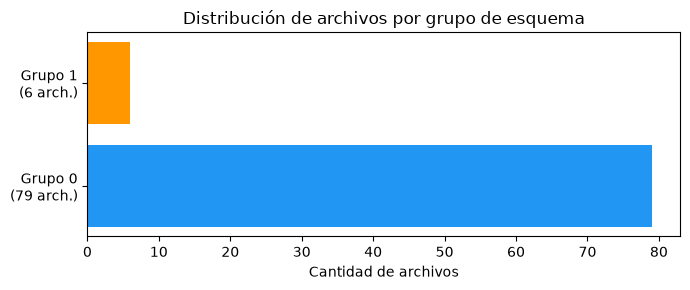

In [8]:
# Gráfico: archivos por grupo de esquema
fig, ax = plt.subplots(figsize=(7, 3))
etiquetas = [f"Grupo {i}\n({len(v)} arch.)" for i, v in enumerate(grupos_esquema.values())]
cantidades = [len(v) for v in grupos_esquema.values()]
ax.barh(etiquetas, cantidades, color=["#2196F3", "#FF9800"][:len(etiquetas)])
ax.set_xlabel("Cantidad de archivos")
ax.set_title("Distribución de archivos por grupo de esquema")
plt.tight_layout()
guardar_figura(fig, "esquema_grupos")
plt.show()


## §3–4 · Auditoría de codificación y consolidación con linaje

In [9]:
# Mapeo de columnas raw → nombres canónicos del proyecto
MAPA_COLUMNAS = {
    # Coordenadas (nombre real en los CSV)
    "origin_latitude":      "lat_orig",
    "origin_longitude":     "lon_orig",
    "destination_latitude": "lat_dest",
    "destination_longitude":"lon_dest",
    # Por si algún archivo trae nombres en español
    "hora": "hour",
    "dia_de_semana": "day_of_week",
    "dia_de_mes": "day_of_month",
    "fin_de_semana": "weekend",
}

# Identificar lote por rango de fechas
def _detectar_lote(nombre_archivo: str) -> str:
    # Formato: 2024-04-29_to_2024-05-05_2024-18.csv  → 4 partes por "_"
    partes = nombre_archivo.split("_")
    año = partes[0][:4]                              # "2024"
    semana_parte = partes[-1].split(".")[0]          # "2024-18"
    semana = int(semana_parte.split("-")[1])          # 18
    if año == "2024" and semana >= 18:
        return "lote_2024_nuevo"
    return "lote_original"

ENCODING_ISSUES.clear()  # reset antes de la lectura completa
dfs: list[pl.DataFrame] = []
reporte_codif: list[dict] = []
filas_por_archivo: dict[str, int] = {}

for ruta in archivos_csv:
    lote = _detectar_lote(ruta.name)
    n_antes = len(ENCODING_ISSUES)
    df_raw = read_csv_safe(ruta, infer_schema_length=10_000)
    uso_latin1 = len(ENCODING_ISSUES) > n_antes

    # Renombrar columnas españolas
    renombres = {k: v for k, v in MAPA_COLUMNAS.items() if k in df_raw.columns}
    if renombres:
        df_raw = df_raw.rename(renombres)

    # Agregar linaje
    df_raw = df_raw.with_columns([
        pl.lit(ruta.name).alias("source_file"),
        pl.lit(lote).alias("source_batch"),
        pl.lit("latin-1" if uso_latin1 else "utf-8").alias("source_encoding"),
    ])

    filas_por_archivo[ruta.name] = len(df_raw)
    reporte_codif.append({
        "archivo": ruta.name,
        "lote": lote,
        "codificacion": "latin-1" if uso_latin1 else "utf-8",
        "filas": len(df_raw),
    })
    dfs.append(df_raw)

print(f"Archivos leídos: {len(dfs)}")
print(f"  Con fallback latin-1: {sum(1 for r in reporte_codif if r['codificacion']=='latin-1')}")


Archivos leídos: 85
  Con fallback latin-1: 6


In [10]:
# Consolidar con diagonal_relaxed (permite columnas opcionales)
df = pl.concat(dfs, how="diagonal_relaxed")

# Verificar conservación de filas
total_esperado = sum(filas_por_archivo.values())
print(f"Filas esperadas (suma individuales): {total_esperado:,}")
print(f"Filas consolidadas:                  {len(df):,}")
print(f"Diferencia:                          {len(df) - total_esperado:,}  ← debe ser 0")
assert len(df) == total_esperado, "¡Pérdida de filas en la consolidación!"

# Guardar reporte de codificación
pl.DataFrame(reporte_codif).write_csv(REPORTE / "reporte_codificacion.csv")
print("\nDistribución por lote:")
print(df.group_by("source_batch").agg(pl.len().alias("n_filas")))


Filas esperadas (suma individuales): 1,927,675
Filas consolidadas:                  1,927,675
Diferencia:                          0  ← debe ser 0

Distribución por lote:
shape: (2, 2)
┌─────────────────┬─────────┐
│ source_batch    ┆ n_filas │
│ ---             ┆ ---     │
│ str             ┆ u32     │
╞═════════════════╪═════════╡
│ lote_2024_nuevo ┆ 161777  │
│ lote_original   ┆ 1765898 │
└─────────────────┴─────────┘


In [11]:
# Parsear timestamp desde 'date' y derivar year/week
if "date" in df.columns:
    df = df.with_columns(
        pl.col("date").str.to_datetime(format="%Y-%m-%d %H:%M:%S", strict=False).alias("ts")
    )
elif "ts" not in df.columns:
    df = df.with_columns(pl.lit(None).cast(pl.Datetime).alias("ts"))

# Derivar year y week desde ts (no existen como columnas en los CSV raw)
if "ts" in df.columns:
    df = df.with_columns([
        pl.col("ts").dt.year().cast(pl.Int32).alias("year"),
        pl.col("ts").dt.week().cast(pl.Int32).alias("week"),
    ])
else:
    df = df.with_columns([
        pl.lit(None).cast(pl.Int32).alias("year"),
        pl.lit(None).cast(pl.Int32).alias("week"),
    ])

print(f"Columnas finales ({len(df.columns)}): {df.columns}")
print(f"\nSchema:")
print(df.schema)


Columnas finales (21): ['date', 'lat_orig', 'lon_orig', 'lat_dest', 'lon_dest', 'userID', 'distancia', 'origin_municipio', 'dest_municipio', 'hour', 'day_of_week', 'day_of_month', 'weekend', 'source_file', 'source_batch', 'source_encoding', 'year_week_number', 'time_of_day', 'ts', 'year', 'week']

Schema:
Schema({'date': String, 'lat_orig': Float64, 'lon_orig': Float64, 'lat_dest': Float64, 'lon_dest': Float64, 'userID': String, 'distancia': Float64, 'origin_municipio': String, 'dest_municipio': String, 'hour': Int64, 'day_of_week': Int64, 'day_of_month': Int64, 'weekend': Int64, 'source_file': String, 'source_batch': String, 'source_encoding': String, 'year_week_number': String, 'time_of_day': String, 'ts': Datetime(time_unit='us', time_zone=None), 'year': Int32, 'week': Int32})


In [12]:
# Matriz cobertura de columnas por lote
columnas_datos = [c for c in df.columns if c not in ("source_file", "source_batch", "source_encoding")]
registros_cob = []
for lote_val in df["source_batch"].unique().to_list():
    df_lote = df.filter(pl.col("source_batch") == lote_val)
    for col in columnas_datos:
        if col in df_lote.columns:
            pct_no_nulo = 1.0 - df_lote[col].is_null().mean()
        else:
            pct_no_nulo = 0.0
        registros_cob.append({"columna": col, "lote": lote_val, "pct_no_nulo": round(pct_no_nulo, 4)})

df_cobertura = pl.DataFrame(registros_cob)
df_cobertura.write_csv(REPORTE / "cobertura_columnas_por_lote.csv")

# Pivotar para visualización
print(df_cobertura.pivot(on="lote", index="columna", values="pct_no_nulo"))


shape: (18, 3)
┌──────────────────┬───────────────┬─────────────────┐
│ columna          ┆ lote_original ┆ lote_2024_nuevo │
│ ---              ┆ ---           ┆ ---             │
│ str              ┆ f64           ┆ f64             │
╞══════════════════╪═══════════════╪═════════════════╡
│ date             ┆ 1.0           ┆ 1.0             │
│ lat_orig         ┆ 1.0           ┆ 1.0             │
│ lon_orig         ┆ 1.0           ┆ 1.0             │
│ lat_dest         ┆ 1.0           ┆ 1.0             │
│ lon_dest         ┆ 1.0           ┆ 1.0             │
│ …                ┆ …             ┆ …               │
│ year_week_number ┆ 0.0           ┆ 1.0             │
│ time_of_day      ┆ 0.0           ┆ 1.0             │
│ ts               ┆ 1.0           ┆ 1.0             │
│ year             ┆ 1.0           ┆ 1.0             │
│ week             ┆ 1.0           ┆ 1.0             │
└──────────────────┴───────────────┴─────────────────┘


In [13]:
# Guardar queries.parquet particionado por year/week
import pyarrow as pa, pyarrow.parquet as pq, pyarrow.dataset as ds

QUERIES_PARQUET.mkdir(parents=True, exist_ok=True)
df_arrow = df.to_arrow()
pq.write_to_dataset(
    df_arrow,
    root_path=str(QUERIES_PARQUET),
    partition_cols=["year", "week"],
    existing_data_behavior="overwrite_or_ignore",
)
print(f"queries.parquet guardado en {QUERIES_PARQUET}")
print(f"  Particiones: {len(list(QUERIES_PARQUET.rglob('*.parquet')))}")


queries.parquet guardado en /home/robvox/Desktop/trufi-data-science/data/interim/queries.parquet
  Particiones: 168


## §5 · Nulidad estratificada y tipada

In [14]:
# 5.1 Nulidad global
nulos_globales = []
for col in df.columns:
    n_nulo = df[col].is_null().sum()
    nulos_globales.append({"columna": col, "n_nulos": n_nulo,
                           "pct_nulos": round(n_nulo / len(df) * 100, 3)})

df_nulos_global = (pl.DataFrame(nulos_globales)
                   .sort("pct_nulos", descending=True))
df_nulos_global.write_csv(REPORTE / "nulos_globales.csv")
print(df_nulos_global.filter(pl.col("pct_nulos") > 0))


shape: (2, 3)
┌──────────────────┬─────────┬───────────┐
│ columna          ┆ n_nulos ┆ pct_nulos │
│ ---              ┆ ---     ┆ ---       │
│ str              ┆ i64     ┆ f64       │
╞══════════════════╪═════════╪═══════════╡
│ year_week_number ┆ 1765898 ┆ 91.608    │
│ time_of_day      ┆ 1765898 ┆ 91.608    │
└──────────────────┴─────────┴───────────┘


In [15]:
# 5.2 Nulidad por lote
nulos_por_lote = (
    df.group_by("source_batch")
    .agg([pl.col(c).is_null().mean().alias(c)
          for c in df.columns if c != "source_batch"])
    .unpivot(index="source_batch", variable_name="columna", value_name="pct_nulos")
    .filter(pl.col("pct_nulos") > 0)
    .sort(["columna", "source_batch"])
)
nulos_por_lote.write_csv(REPORTE / "nulos_por_lote.csv")
print("Columnas con nulidad > 0% en algún lote:")
print(nulos_por_lote)


Columnas con nulidad > 0% en algún lote:
shape: (2, 3)
┌───────────────┬──────────────────┬───────────┐
│ source_batch  ┆ columna          ┆ pct_nulos │
│ ---           ┆ ---              ┆ ---       │
│ str           ┆ str              ┆ f64       │
╞═══════════════╪══════════════════╪═══════════╡
│ lote_original ┆ time_of_day      ┆ 1.0       │
│ lote_original ┆ year_week_number ┆ 1.0       │
└───────────────┴──────────────────┴───────────┘


In [16]:
# 5.3 Nulidad por mes
if "ts" in df.columns and df["ts"].is_not_null().any():
    df_con_mes = df.with_columns(
        pl.col("ts").dt.strftime("%Y-%m").alias("anio_mes")
    )
    nulos_por_mes_lista = []
    for col in ["userID", "lat_orig", "lon_orig", "lat_dest", "lon_dest",
                "distancia", "origin_municipio", "dest_municipio", "hour", "weekend"]:
        if col not in df.columns:
            continue
        agg = (df_con_mes.group_by("anio_mes")
               .agg(pl.col(col).is_null().mean().alias("pct_nulos"))
               .with_columns(pl.lit(col).alias("columna"))
               .sort("anio_mes"))
        nulos_por_mes_lista.append(agg)
    if nulos_por_mes_lista:
        nulos_mes = pl.concat(nulos_por_mes_lista)
        nulos_mes.write_csv(REPORTE / "nulos_por_mes.csv")
        print("Guardado nulos_por_mes.csv")
    else:
        print("No hay columnas para analizar nulidad mensual")
else:
    print("ts no disponible — omitiendo nulidad por mes")


Guardado nulos_por_mes.csv


In [17]:
# 5.4 Correlación de nulidad (co-faltantes)
cols_con_nulos = [c for c in df.columns
                  if df[c].is_null().any() and c not in ("source_file","source_batch","source_encoding")]
if cols_con_nulos:
    indicadores_nulos = df.select([pl.col(c).is_null().cast(pl.Int8).alias(c) for c in cols_con_nulos])
    corr_nulos = indicadores_nulos.to_pandas().corr(method="pearson")
    corr_nulos.to_csv(REPORTE / "nulos_correlacion.csv")
    print(f"Matriz de correlación de nulidad guardada ({len(cols_con_nulos)} columnas)")
    print(corr_nulos.round(3))
else:
    print("Sin columnas con nulos — matriz vacía")


Matriz de correlación de nulidad guardada (2 columnas)
                  year_week_number  time_of_day
year_week_number               1.0          1.0
time_of_day                    1.0          1.0


In [18]:
# 5.5 Clasificación textual de nulidad por columna
# Tipos: ESTRUCTURAL / MAR / MNAR / CERO_COMO_NULO
clasificacion_nulidad = {
    "year_week_number": "ESTRUCTURAL",   # solo en lote_2024_nuevo
    "time_of_day":      "ESTRUCTURAL",   # solo en lote_2024_nuevo
    "ts":               "MAR",           # ocasional, no correlaciona con lote
    "distancia":        "MAR",           # proporción pequeña, aleatoria
    "origin_municipio": "MNAR",          # puede correlacionar con zona geográfica
    "dest_municipio":   "MNAR",          # ídem
    "lat_orig":         "CERO_COMO_NULO",  # (0,0) representa datos faltantes
    "lon_orig":         "CERO_COMO_NULO",
    "lat_dest":         "CERO_COMO_NULO",
    "lon_dest":         "CERO_COMO_NULO",
}
print("Clasificación de tipos de nulidad:")
for col, tipo in clasificacion_nulidad.items():
    if col in df.columns:
        pct = df[col].is_null().mean() * 100
        print(f"  {col:<25} {tipo:<20} ({pct:.2f}% nulos)")


Clasificación de tipos de nulidad:
  year_week_number          ESTRUCTURAL          (91.61% nulos)
  time_of_day               ESTRUCTURAL          (91.61% nulos)
  ts                        MAR                  (0.00% nulos)
  distancia                 MAR                  (0.00% nulos)
  origin_municipio          MNAR                 (0.00% nulos)
  dest_municipio            MNAR                 (0.00% nulos)
  lat_orig                  CERO_COMO_NULO       (0.00% nulos)
  lon_orig                  CERO_COMO_NULO       (0.00% nulos)
  lat_dest                  CERO_COMO_NULO       (0.00% nulos)
  lon_dest                  CERO_COMO_NULO       (0.00% nulos)


## §6 · Duplicados — 4 definiciones + solapamiento

In [19]:
# Columnas para cada definición
def_duplicados = {}
cols_od_ts = ["lat_orig", "lon_orig", "lat_dest", "lon_dest", "ts"]
cols_uid_ts = ["userID", "ts"]
cols_od_ts_uid = ["lat_orig", "lon_orig", "lat_dest", "lon_dest", "ts", "userID"]
cols_exacto = [c for c in df.columns if c not in ("source_file", "source_batch", "source_encoding")]

definiciones = {
    "exacto": cols_exacto,
    "od_ts":  [c for c in cols_od_ts if c in df.columns],
    "uid_ts": [c for c in cols_uid_ts if c in df.columns],
    "od_ts_uid": [c for c in cols_od_ts_uid if c in df.columns],
}

resumen_dups = []
indices_dups: dict[str, pl.Series] = {}

for nombre_def, columnas_def in definiciones.items():
    if not columnas_def:
        print(f"Definición '{nombre_def}' sin columnas disponibles — omitida")
        continue
    mascara_dup = df.select(columnas_def).is_duplicated()
    n_dup = mascara_dup.sum()
    resumen_dups.append({
        "definicion": nombre_def,
        "columnas_usadas": len(columnas_def),
        "n_duplicados": n_dup,
        "pct_duplicados": round(n_dup / len(df) * 100, 4),
    })
    indices_dups[nombre_def] = mascara_dup
    # Desglose por lote
    for lote_val in df["source_batch"].unique().to_list():
        mask_lote = (df["source_batch"] == lote_val) & mascara_dup
        print(f"  {nombre_def} | {lote_val}: {mask_lote.sum():,} duplicados")

df_dup_resumen = pl.DataFrame(resumen_dups)
df_dup_resumen.write_csv(REPORTE / "duplicados_resumen.csv")
print("\nResumen:")
print(df_dup_resumen)


  exacto | lote_original: 102 duplicados
  exacto | lote_2024_nuevo: 2 duplicados


  od_ts | lote_original: 102 duplicados
  od_ts | lote_2024_nuevo: 2 duplicados


  uid_ts | lote_2024_nuevo: 2 duplicados
  uid_ts | lote_original: 135 duplicados


  od_ts_uid | lote_original: 102 duplicados
  od_ts_uid | lote_2024_nuevo: 2 duplicados

Resumen:
shape: (4, 4)
┌────────────┬─────────────────┬──────────────┬────────────────┐
│ definicion ┆ columnas_usadas ┆ n_duplicados ┆ pct_duplicados │
│ ---        ┆ ---             ┆ ---          ┆ ---            │
│ str        ┆ i64             ┆ i64          ┆ f64            │
╞════════════╪═════════════════╪══════════════╪════════════════╡
│ exacto     ┆ 18              ┆ 104          ┆ 0.0054         │
│ od_ts      ┆ 5               ┆ 104          ┆ 0.0054         │
│ uid_ts     ┆ 2               ┆ 137          ┆ 0.0071         │
│ od_ts_uid  ┆ 6               ┆ 104          ┆ 0.0054         │
└────────────┴─────────────────┴──────────────┴────────────────┘


In [20]:
# Muestra de 5 duplicados exactos para confirmar que son artefactos ETL
if "exacto" in indices_dups:
    mask_exacto = indices_dups["exacto"]
    print("Muestra de 5 filas duplicadas exactas:")
    cols_muestra = ["source_file", "userID", "ts", "lat_orig", "lon_orig", "lat_dest", "lon_dest"]
    cols_muestra = [c for c in cols_muestra if c in df.columns]
    print(df.filter(mask_exacto).select(cols_muestra).head(5))


Muestra de 5 filas duplicadas exactas:
shape: (5, 7)
┌───────────────┬───────────────┬──────────────┬────────────┬────────────┬────────────┬────────────┐
│ source_file   ┆ userID        ┆ ts           ┆ lat_orig   ┆ lon_orig   ┆ lat_dest   ┆ lon_dest   │
│ ---           ┆ ---           ┆ ---          ┆ ---        ┆ ---        ┆ ---        ┆ ---        │
│ str           ┆ str           ┆ datetime[μs] ┆ f64        ┆ f64        ┆ f64        ┆ f64        │
╞═══════════════╪═══════════════╪══════════════╪════════════╪════════════╪════════════╪════════════╡
│ 2022-11-14_to ┆ cdf9e3c9-426c ┆ 2022-11-17   ┆ -17.36555  ┆ -66.160139 ┆ -17.373035 ┆ -66.153672 │
│ _2022-11-20_2 ┆ -4677-aa5b-56 ┆ 09:57:48     ┆            ┆            ┆            ┆            │
│ 022-…         ┆ 7468…         ┆              ┆            ┆            ┆            ┆            │
│ 2022-11-14_to ┆ cdf9e3c9-426c ┆ 2022-11-17   ┆ -17.36555  ┆ -66.160139 ┆ -17.373035 ┆ -66.153672 │
│ _2022-11-20_2 ┆ -4677-aa5b-56 ┆ 09:5

In [21]:
# Matriz de solapamiento (Jaccard) entre definiciones
nombres_defs = list(indices_dups.keys())
jaccard_data = []
for i, a in enumerate(nombres_defs):
    fila = {}
    set_a = set(np.where(indices_dups[a].to_numpy())[0])
    for j, b in enumerate(nombres_defs):
        set_b = set(np.where(indices_dups[b].to_numpy())[0])
        inter = len(set_a & set_b)
        union = len(set_a | set_b)
        fila[b] = round(inter / union, 4) if union > 0 else 1.0
    jaccard_data.append({"definicion": a, **fila})

df_jaccard = pl.DataFrame(jaccard_data)
df_jaccard.write_csv(REPORTE / "duplicados_solapamiento.csv")
print("Matriz de solapamiento Jaccard:")
print(df_jaccard)


Matriz de solapamiento Jaccard:
shape: (4, 5)
┌────────────┬────────┬────────┬────────┬───────────┐
│ definicion ┆ exacto ┆ od_ts  ┆ uid_ts ┆ od_ts_uid │
│ ---        ┆ ---    ┆ ---    ┆ ---    ┆ ---       │
│ str        ┆ f64    ┆ f64    ┆ f64    ┆ f64       │
╞════════════╪════════╪════════╪════════╪═══════════╡
│ exacto     ┆ 1.0    ┆ 1.0    ┆ 0.7591 ┆ 1.0       │
│ od_ts      ┆ 1.0    ┆ 1.0    ┆ 0.7591 ┆ 1.0       │
│ uid_ts     ┆ 0.7591 ┆ 0.7591 ┆ 1.0    ┆ 0.7591    │
│ od_ts_uid  ┆ 1.0    ┆ 1.0    ┆ 0.7591 ┆ 1.0       │
└────────────┴────────┴────────┴────────┴───────────┘


In [22]:
# Impacto de cada definición en las top-20 celdas de origen
if "h3_orig" in df.columns or "lat_orig" in df.columns:
    import h3 as _h3
    col_orig = "h3_orig" if "h3_orig" in df.columns else None
    if col_orig is None:
        df_h3 = df.filter(
            pl.col("lat_orig").is_not_null() & (pl.col("lat_orig") != 0.0)
        ).with_columns(
            pl.struct(["lat_orig", "lon_orig"])
            .map_elements(lambda r: _h3.latlng_to_cell(r["lat_orig"], r["lon_orig"], H3_RESOLUTION_DEFAULT),
                          return_dtype=pl.Utf8)
            .alias("h3_orig_temp")
        )
        col_orig = "h3_orig_temp"
    else:
        df_h3 = df

    top20_celdas = (df_h3.group_by(col_orig).agg(pl.len().alias("n_consultas"))
                    .sort("n_consultas", descending=True).head(20)[col_orig].to_list())

    impacto = []
    for nombre_def, columnas_def in definiciones.items():
        if not columnas_def:
            continue
        # Recompute mask on df_h3 (subset filtered of zero/impossible coords)
        cols_def_h3 = [c for c in columnas_def if c in df_h3.columns]
        if not cols_def_h3:
            continue
        mask_h3 = df_h3.select(cols_def_h3).is_duplicated()
        df_no_dup = df_h3.filter(~mask_h3)
        for celda in top20_celdas:
            n_orig = df_h3.filter(pl.col(col_orig) == celda).height
            n_tras = df_no_dup.filter(pl.col(col_orig) == celda).height
            perdida = n_orig - n_tras
            impacto.append({"celda": celda, "definicion": nombre_def,
                            "n_original": n_orig, "n_tras_dedup": n_tras,
                            "filas_perdidas": perdida,
                            "pct_perdida": round(perdida/n_orig*100, 3) if n_orig>0 else 0.0})

    pl.DataFrame(impacto).write_csv(REPORTE / "duplicados_impacto_celdas.csv")
    print("Guardado duplicados_impacto_celdas.csv")


Guardado duplicados_impacto_celdas.csv


## §7 · Clasificación espacial de 3 vías

In [23]:
# BBOX amplio de Bolivia para detectar coordenadas imposibles
BBOX_BOLIVIA = {"lat_min": -23.0, "lat_max": -9.0, "lon_min": -70.0, "lon_max": -56.0}

def clasificar_coordenadas(df_in: pl.DataFrame) -> pl.DataFrame:
    """Añade flags de clasificación espacial para coordenadas de origen."""
    lat = pl.col("lat_orig")
    lon = pl.col("lon_orig")
    return df_in.with_columns([
        # 1. Coordenada cero (Null Island — bug de GPS)
        ((lat == 0.0) | (lon == 0.0)).alias("flag_coord_cero"),
        # 2. Fuera de Bolivia (coordenada físicamente imposible)
        (~((lat >= BBOX_BOLIVIA["lat_min"]) & (lat <= BBOX_BOLIVIA["lat_max"]) &
           (lon >= BBOX_BOLIVIA["lon_min"]) & (lon <= BBOX_BOLIVIA["lon_max"])
          ) & (lat != 0.0) & (lon != 0.0)).alias("flag_coord_imposible"),
        # 3. Fuera del eje metropolitano pero dentro de Bolivia
        ((lat >= BBOX_BOLIVIA["lat_min"]) & (lat <= BBOX_BOLIVIA["lat_max"]) &
         (lon >= BBOX_BOLIVIA["lon_min"]) & (lon <= BBOX_BOLIVIA["lon_max"]) &
         ~((lat >= BBOX["lat_min"]) & (lat <= BBOX["lat_max"]) &
           (lon >= BBOX["lon_min"]) & (lon <= BBOX["lon_max"])) &
         (lat != 0.0) & (lon != 0.0)
        ).alias("flag_fuera_eje"),
    ])

df = clasificar_coordenadas(df)
print("Clasificación espacial de coordenadas de ORIGEN:")
for flag in ["flag_coord_cero", "flag_coord_imposible", "flag_fuera_eje"]:
    n = df[flag].sum()
    pct = n / len(df) * 100
    print(f"  {flag}: {n:,} ({pct:.3f}%)")


Clasificación espacial de coordenadas de ORIGEN:
  flag_coord_cero: 3 (0.000%)
  flag_coord_imposible: 9 (0.000%)
  flag_fuera_eje: 1,204 (0.062%)


In [24]:
# Guardar tablas por categoría
for flag, nombre_csv in [
    ("flag_coord_cero", "coordenadas_cero.csv"),
    ("flag_coord_imposible", "coordenadas_imposibles.csv"),
    ("flag_fuera_eje", "coordenadas_fuera_de_eje.csv"),
]:
    cols_out = [c for c in ["source_file","source_batch","userID","ts",
                            "lat_orig","lon_orig","lat_dest","lon_dest",
                            "origin_municipio","dest_municipio"] if c in df.columns]
    df.filter(pl.col(flag)).select(cols_out).write_csv(REPORTE / nombre_csv)

# Top 10 municipios destino de viajes fuera del eje (¿interurbanos legítimos?)
if "dest_municipio" in df.columns:
    print("\nTop 10 municipios destino en viajes fuera del eje metropolitano:")
    print(df.filter(pl.col("flag_fuera_eje"))
          .group_by("dest_municipio").agg(pl.len().alias("n"))
          .sort("n", descending=True).head(10))



Top 10 municipios destino en viajes fuera del eje metropolitano:
shape: (10, 2)
┌────────────────┬─────┐
│ dest_municipio ┆ n   │
│ ---            ┆ --- │
│ str            ┆ u32 │
╞════════════════╪═════╡
│ Cochabamba     ┆ 953 │
│ Sacaba         ┆ 56  │
│ Quillacollo    ┆ 53  │
│ Tiquipaya      ┆ 46  │
│ Colcapirhua    ┆ 25  │
│ Villa Punata   ┆ 14  │
│ externo        ┆ 11  │
│ Tarata         ┆ 7   │
│ Arani          ┆ 6   │
│ Sipesipe       ┆ 6   │
└────────────────┴─────┘


In [25]:
# Imprimir las filas con coordenadas físicamente imposibles
if df["flag_coord_imposible"].sum() > 0:
    cols_imp = [c for c in ["source_file","lat_orig","lon_orig","lat_dest","lon_dest",
                            "origin_municipio","dest_municipio"] if c in df.columns]
    print("Filas con coordenadas imposibles:")
    print(df.filter(pl.col("flag_coord_imposible")).select(cols_imp))


Filas con coordenadas imposibles:


shape: (9, 7)
┌───────────────┬────────────┬────────────┬────────────┬────────────┬───────────────┬──────────────┐
│ source_file   ┆ lat_orig   ┆ lon_orig   ┆ lat_dest   ┆ lon_dest   ┆ origin_munici ┆ dest_municip │
│ ---           ┆ ---        ┆ ---        ┆ ---        ┆ ---        ┆ pio           ┆ io           │
│ str           ┆ f64        ┆ f64        ┆ f64        ┆ f64        ┆ ---           ┆ ---          │
│               ┆            ┆            ┆            ┆            ┆ str           ┆ str          │
╞═══════════════╪════════════╪════════════╪════════════╪════════════╪═══════════════╪══════════════╡
│ 2024-04-29_to ┆ 13.748923  ┆ -89.033979 ┆ -17.444641 ┆ -66.123199 ┆ externo       ┆ Cochabamba   │
│ _2024-05-05_2 ┆            ┆            ┆            ┆            ┆               ┆              │
│ 024-…         ┆            ┆            ┆            ┆            ┆               ┆              │
│ 2024-04-29_to ┆ 13.748923  ┆ -89.033979 ┆ -17.379983 ┆ -66.138967 ┆ externo

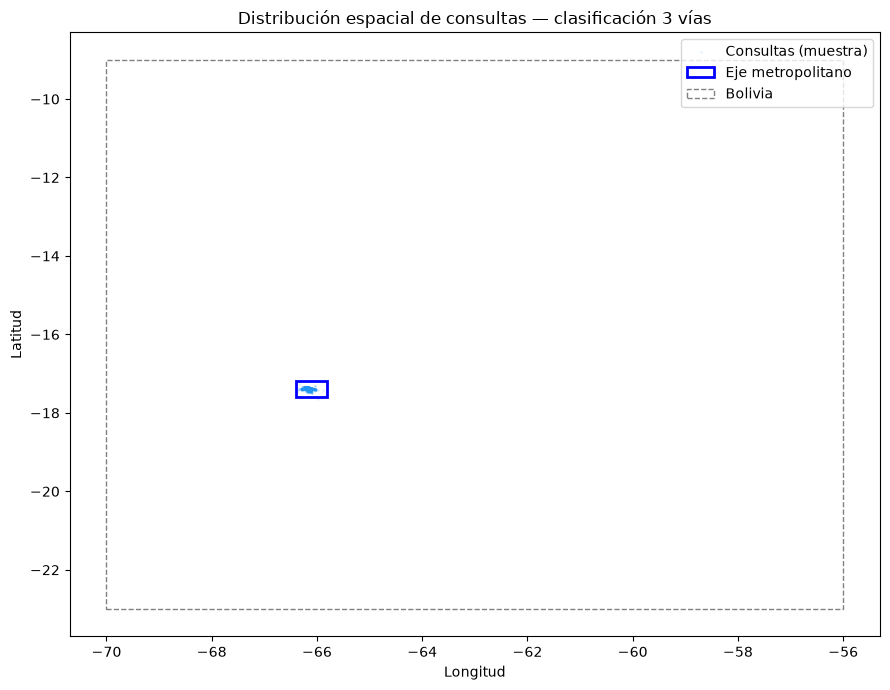

In [26]:
# Mapa de 3 capas: puntos de consulta, bbox metro, bbox Bolivia
fig, ax = plt.subplots(figsize=(9, 7))

# Capa 1: puntos de consulta (muestra de 5k — sin flags problemáticos)
df_mapa = df.filter(
    ~pl.col("flag_coord_cero") & ~pl.col("flag_coord_imposible")
).sample(min(5000, len(df)), seed=42)
if len(df_mapa) > 0:
    ax.scatter(df_mapa["lon_orig"].to_numpy(), df_mapa["lat_orig"].to_numpy(),
               alpha=0.08, s=1, color="#2196F3", label="Consultas (muestra)")

# Capa 2: bbox metropolitano
from matplotlib.patches import Rectangle
rect_metro = Rectangle(
    (BBOX["lon_min"], BBOX["lat_min"]),
    BBOX["lon_max"] - BBOX["lon_min"],
    BBOX["lat_max"] - BBOX["lat_min"],
    linewidth=2, edgecolor="blue", facecolor="none", label="Eje metropolitano"
)
ax.add_patch(rect_metro)

# Capa 3: bbox Bolivia
rect_bolivia = Rectangle(
    (BBOX_BOLIVIA["lon_min"], BBOX_BOLIVIA["lat_min"]),
    BBOX_BOLIVIA["lon_max"] - BBOX_BOLIVIA["lon_min"],
    BBOX_BOLIVIA["lat_max"] - BBOX_BOLIVIA["lat_min"],
    linewidth=1, edgecolor="gray", facecolor="none", linestyle="--", label="Bolivia"
)
ax.add_patch(rect_bolivia)

ax.set_xlabel("Longitud"); ax.set_ylabel("Latitud")
ax.set_title("Distribución espacial de consultas — clasificación 3 vías")
ax.legend()
plt.tight_layout()
guardar_figura(fig, "clasificacion_espacial_3_vias")
plt.show()


## §8 · Verificación de `distancia`

In [27]:
from trufi_ds.spatial import haversine_km

# Muestra para verificación de unidades
df_muestra_dist = df.filter(
    pl.col("distancia").is_not_null() &
    ~pl.col("flag_coord_cero") & ~pl.col("flag_coord_imposible")
).sample(min(200_000, df.filter(pl.col("distancia").is_not_null()).height), seed=42)

dist_raw = df_muestra_dist["distancia"].to_numpy()

# Recalcular haversine en metros
haversine_m_arr = np.array([
    haversine_km(r["lat_orig"], r["lon_orig"], r["lat_dest"], r["lon_dest"]) * 1000
    for r in df_muestra_dist.select(["lat_orig","lon_orig","lat_dest","lon_dest"]).iter_rows(named=True)
])

# Hipótesis metros: comparar directamente
mascara_valida = (haversine_m_arr > 0) & np.isfinite(haversine_m_arr) & np.isfinite(dist_raw)
error_metros = np.abs(dist_raw[mascara_valida] - haversine_m_arr[mascara_valida]) / haversine_m_arr[mascara_valida]
error_km     = np.abs(dist_raw[mascara_valida] - haversine_m_arr[mascara_valida] / 1000) / (haversine_m_arr[mascara_valida] / 1000)

corr = np.corrcoef(dist_raw[mascara_valida], haversine_m_arr[mascara_valida])[0, 1]

resultado_unidad = {
    "correlacion_pearson": round(corr, 6),
    "error_mediano_hipotesis_metros_pct": round(np.median(error_metros[np.isfinite(error_metros)]) * 100, 4),
    "error_mediano_hipotesis_km_pct": round(np.median(error_km[np.isfinite(error_km)]) * 100, 4),
}
print(resultado_unidad)
pl.DataFrame([resultado_unidad]).write_csv(REPORTE / "distancia_verificacion_unidad.csv")

unidad_detectada = "metros" if resultado_unidad["error_mediano_hipotesis_metros_pct"] < resultado_unidad["error_mediano_hipotesis_km_pct"] else "km"
print(f"\n→ Unidad detectada: {unidad_detectada} (error mediano {resultado_unidad['error_mediano_hipotesis_metros_pct']:.2f}%)")


{'correlacion_pearson': np.float64(0.999997), 'error_mediano_hipotesis_metros_pct': np.float64(0.1419), 'error_mediano_hipotesis_km_pct': np.float64(99766.4611)}

→ Unidad detectada: metros (error mediano 0.14%)


In [28]:
# Percentiles y distribución
percentiles_dist = np.percentile(
    dist_raw[np.isfinite(dist_raw) & (dist_raw > 0)],
    [1, 5, 25, 50, 75, 95, 99, 100]
)
etiquetas_pct = ["P1","P5","P25","P50","P75","P95","P99","max"]
df_percentiles = pl.DataFrame({"percentil": etiquetas_pct,
                                "distancia_m": [round(p, 1) for p in percentiles_dist]})
df_percentiles.write_csv(REPORTE / "distancia_percentiles.csv")
print(df_percentiles)

# Filas con distancia > 40 km
umbral_40km = 40_000
df_lejos = df.filter(pl.col("distancia") > umbral_40km)
if "origin_municipio" in df.columns:
    resumen_lejos = df_lejos.group_by("origin_municipio").agg(pl.len().alias("n")).sort("n", descending=True)
    resumen_lejos.write_csv(REPORTE / "distancia_sobre_umbral.csv")
    print(f"\nViajes > 40 km: {len(df_lejos):,} ({len(df_lejos)/len(df)*100:.2f}%)")
    print(resumen_lejos.head(10))


shape: (8, 2)
┌───────────┬─────────────┐
│ percentil ┆ distancia_m │
│ ---       ┆ ---         │
│ str       ┆ f64         │
╞═══════════╪═════════════╡
│ P1        ┆ 620.7       │
│ P5        ┆ 975.6       │
│ P25       ┆ 2040.2      │
│ P50       ┆ 3403.2      │
│ P75       ┆ 5972.5      │
│ P95       ┆ 13060.3     │
│ P99       ┆ 19565.0     │
│ max       ┆ 484549.7    │
└───────────┴─────────────┘



Viajes > 40 km: 2,106 (0.11%)
shape: (10, 2)
┌───────────────────┬─────┐
│ origin_municipio  ┆ n   │
│ ---               ┆ --- │
│ str               ┆ u32 │
╞═══════════════════╪═════╡
│ Cochabamba        ┆ 839 │
│ externo           ┆ 271 │
│ Quillacollo       ┆ 205 │
│ Villa Punata      ┆ 133 │
│ Villa Tunari      ┆ 82  │
│ Colcapirhua       ┆ 82  │
│ Tiquipaya         ┆ 72  │
│ Arani             ┆ 51  │
│ Sacaba            ┆ 40  │
│ Puerto Villarroel ┆ 33  │
└───────────────────┴─────┘


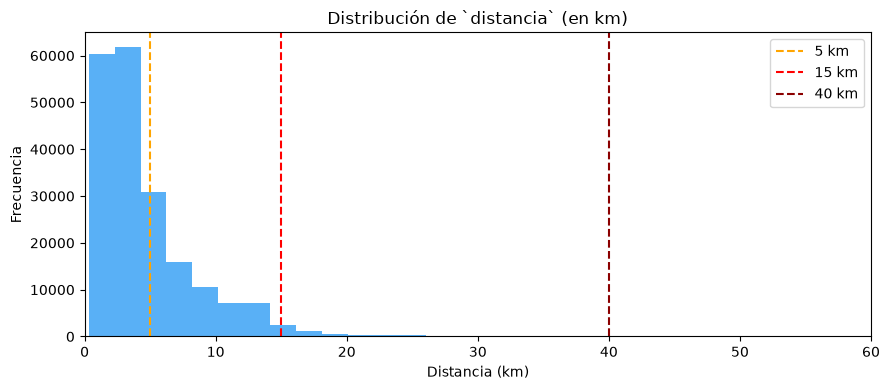

In [29]:
# Histograma de distancia con líneas verticales
dist_limpio = dist_raw[np.isfinite(dist_raw) & (dist_raw > 0) & (dist_raw < 200_000)]
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(dist_limpio / 1000, bins=100, color="#2196F3", alpha=0.75)
for km_val, color, etiq in [(5, "orange", "5 km"), (15, "red", "15 km"), (40, "darkred", "40 km")]:
    ax.axvline(km_val, color=color, linestyle="--", linewidth=1.5, label=etiq)
ax.set_xlabel("Distancia (km)"); ax.set_ylabel("Frecuencia")
ax.set_title("Distribución de `distancia` (en km)")
ax.legend()
ax.set_xlim(0, 60)
plt.tight_layout()
guardar_figura(fig, "distancia_distribucion")
plt.show()


## §9 · Cobertura temporal

In [30]:
# Conteo semanal y semanas faltantes
df_semanal = (df.group_by(["year","week"])
              .agg(pl.len().alias("n_consultas"))
              .sort(["year","week"]))

# Generar todas las semanas esperadas entre primera y última
primera = df_semanal.head(1).select(["year","week"]).row(0)
ultima  = df_semanal.tail(1).select(["year","week"]).row(0)

semanas_observadas = set(tuple(r) for r in df_semanal.select(["year","week"]).iter_rows())

# Generar semanas esperadas (aproximación: todas las semanas ISO entre rango)
import datetime
semanas_esperadas = set()
fecha = datetime.date.fromisocalendar(primera[0], max(primera[1], 1), 1)
fecha_fin = datetime.date.fromisocalendar(ultima[0], ultima[1], 7)
while fecha <= fecha_fin:
    iso = fecha.isocalendar()
    semanas_esperadas.add((iso[0], iso[1]))
    fecha += datetime.timedelta(weeks=1)

semanas_faltantes = sorted(semanas_esperadas - semanas_observadas)
print(f"Semanas esperadas: {len(semanas_esperadas)}")
print(f"Semanas observadas: {len(semanas_observadas)}")
print(f"Semanas faltantes: {len(semanas_faltantes)}")
print("  Faltantes:", semanas_faltantes[:10])

pl.DataFrame([{"year": y, "week": w} for y, w in semanas_faltantes]).write_csv(REPORTE / "semanas_faltantes.csv")


Semanas esperadas: 91
Semanas observadas: 84
Semanas faltantes: 7
  Faltantes: [(2024, 11), (2024, 12), (2024, 13), (2024, 14), (2024, 15), (2024, 16), (2024, 17)]


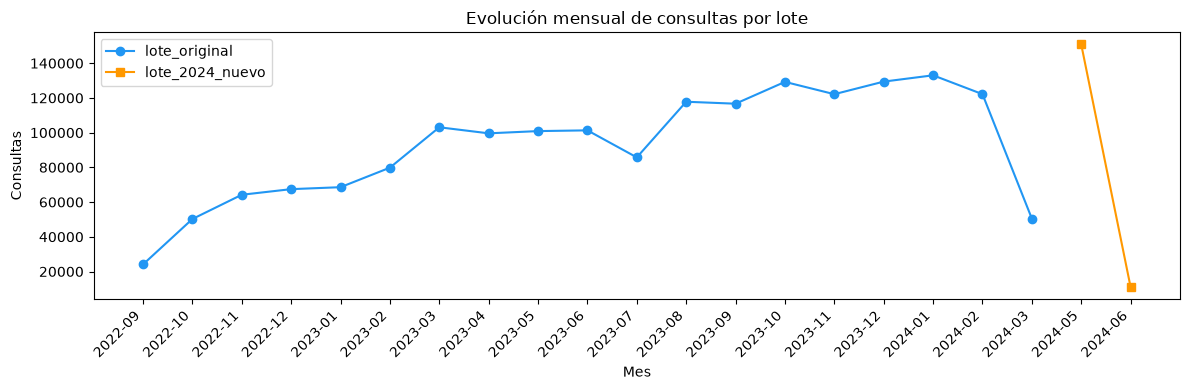

In [31]:
# Cobertura mensual por lote
if "ts" in df.columns and df["ts"].is_not_null().any():
    df_mensual = (df
        .with_columns(pl.col("ts").dt.strftime("%Y-%m").alias("anio_mes"))
        .group_by(["anio_mes","source_batch"])
        .agg(pl.len().alias("n_consultas"))
        .sort(["anio_mes","source_batch"]))
    df_mensual.write_csv(REPORTE / "cobertura_mensual_por_lote.csv")

    # Gráfico: volumen mensual con línea de cambio de lote
    fig, ax = plt.subplots(figsize=(12, 4))
    for lote_val, color, marcador in [("lote_original","#2196F3","o"), ("lote_2024_nuevo","#FF9800","s")]:
        sub = df_mensual.filter(pl.col("source_batch") == lote_val).sort("anio_mes")
        if len(sub) == 0:
            continue
        meses = sub["anio_mes"].to_list()
        ns = sub["n_consultas"].to_list()
        ax.plot(meses, ns, marker=marcador, label=lote_val, color=color)
    ax.set_xlabel("Mes"); ax.set_ylabel("Consultas")
    ax.set_title("Evolución mensual de consultas por lote")
    ax.legend(); plt.xticks(rotation=45, ha="right"); plt.tight_layout()
    guardar_figura(fig, "cobertura_mensual_por_lote")
    plt.show()


In [32]:
# Cobertura temporal por celda H3 de origen
if "lat_orig" in df.columns and df["lat_orig"].is_not_null().any():
    import h3 as _h3
    df_cob_celda = (
        df.filter(~pl.col("flag_coord_cero") & ~pl.col("flag_coord_imposible"))
        .with_columns(
            pl.struct(["lat_orig","lon_orig"])
            .map_elements(lambda r: _h3.latlng_to_cell(r["lat_orig"], r["lon_orig"], H3_RESOLUTION_DEFAULT),
                          return_dtype=pl.Utf8)
            .alias("h3_orig")
        )
    )
    if "ts" in df_cob_celda.columns and df_cob_celda["ts"].is_not_null().any():
        cob_celda = (df_cob_celda
                     .filter(pl.col("h3_orig").is_not_null())
                     .group_by("h3_orig")
                     .agg([
                         pl.col("ts").dt.date().n_unique().alias("dias_con_datos"),
                         pl.col("ts").dt.date().min().alias("primera_fecha"),
                         pl.col("ts").dt.date().max().alias("ultima_fecha"),
                     ])
                     .sort("dias_con_datos", descending=True))
        cob_celda.write_csv(REPORTE / "cobertura_temporal_celda.csv")
        print("Cobertura temporal por celda (top 10):")
        print(cob_celda.head(10))


Cobertura temporal por celda (top 10):
shape: (10, 4)
┌─────────────────┬────────────────┬───────────────┬──────────────┐
│ h3_orig         ┆ dias_con_datos ┆ primera_fecha ┆ ultima_fecha │
│ ---             ┆ ---            ┆ ---           ┆ ---          │
│ str             ┆ u32            ┆ date          ┆ date         │
╞═════════════════╪════════════════╪═══════════════╪══════════════╡
│ 888b2c8a3bfffff ┆ 565            ┆ 2022-09-12    ┆ 2024-06-03   │
│ 888b2c8a31fffff ┆ 564            ┆ 2022-09-13    ┆ 2024-06-03   │
│ 888b2c8ae5fffff ┆ 564            ┆ 2022-09-13    ┆ 2024-06-03   │
│ 888b2c8aedfffff ┆ 564            ┆ 2022-09-12    ┆ 2024-06-03   │
│ 888b2c8a33fffff ┆ 564            ┆ 2022-09-12    ┆ 2024-06-03   │
│ 888b2c8a03fffff ┆ 564            ┆ 2022-09-12    ┆ 2024-06-03   │
│ 888b2c80e5fffff ┆ 564            ┆ 2022-09-13    ┆ 2024-06-03   │
│ 888b2c8a39fffff ┆ 564            ┆ 2022-09-13    ┆ 2024-06-03   │
│ 888b2c8a15fffff ┆ 564            ┆ 2022-09-12    ┆ 2024-06-0

## §10 · `userID` — 6 señales de anomalía

In [33]:
# Estadísticas base por usuario
if "h3_orig" not in df.columns:
    import h3 as _h3
    df_usuarios = (df.filter(~pl.col("flag_coord_cero") & ~pl.col("flag_coord_imposible"))
                   .with_columns(
                       pl.struct(["lat_orig","lon_orig"])
                       .map_elements(lambda r: _h3.latlng_to_cell(r["lat_orig"], r["lon_orig"], H3_RESOLUTION_DEFAULT),
                                     return_dtype=pl.Utf8)
                       .alias("h3_orig")
                   ))
else:
    df_usuarios = df

# Agregar por usuario
stats_usuario = (
    df_usuarios.filter(pl.col("userID").is_not_null())
    .group_by("userID")
    .agg([
        pl.len().alias("n_consultas"),
        pl.col("ts").dt.date().n_unique().alias("dias_activos"),
        pl.col("h3_orig").n_unique().alias("n_celdas_distintas"),
    ])
)
print(f"Usuarios únicos: {len(stats_usuario):,}")
print(stats_usuario.describe())


Usuarios únicos: 130,545
shape: (9, 5)
┌────────────┬─────────────────────────────────┬─────────────┬──────────────┬────────────────────┐
│ statistic  ┆ userID                          ┆ n_consultas ┆ dias_activos ┆ n_celdas_distintas │
│ ---        ┆ ---                             ┆ ---         ┆ ---          ┆ ---                │
│ str        ┆ str                             ┆ f64         ┆ f64          ┆ f64                │
╞════════════╪═════════════════════════════════╪═════════════╪══════════════╪════════════════════╡
│ count      ┆ 130545                          ┆ 130545.0    ┆ 130545.0     ┆ 130545.0           │
│ null_count ┆ 0                               ┆ 0.0         ┆ 0.0          ┆ 0.0                │
│ mean       ┆ null                            ┆ 14.766272   ┆ 5.722318     ┆ 4.547666           │
│ std        ┆ null                            ┆ 31.878924   ┆ 9.929754     ┆ 5.652355           │
│ min        ┆ 00006001-423a-4efc-9cd9-6d8037… ┆ 1.0         ┆ 1.0    

In [34]:
# Señal 1: n_consultas > 1000
# Señal 2: n_consultas / dias_activos > 50 (intensidad diaria)
# Señal 3: n_celdas_distintas > 200 (dispersión espacial excesiva)
stats_usuario = stats_usuario.with_columns([
    (pl.col("n_consultas") / pl.col("dias_activos").clip(lower_bound=1)).alias("tasa_diaria"),
])

# Señal 4: max_consultas_en_un_dia (ráfaga)
max_por_dia = (
    df_usuarios.filter(pl.col("userID").is_not_null() & pl.col("ts").is_not_null())
    .with_columns(pl.col("ts").dt.date().alias("fecha"))
    .group_by(["userID","fecha"]).agg(pl.len().alias("n"))
    .group_by("userID").agg(pl.col("n").max().alias("max_consultas_dia"))
)
stats_usuario = stats_usuario.join(max_por_dia, on="userID", how="left")


In [35]:
# Señal 5: pct_pares_OD_repetidos (rutina)
if "h3_orig" in df_usuarios.columns and "lat_dest" in df_usuarios.columns:
    import h3 as _h3
    df_h3_dest = df_usuarios.with_columns(
        pl.struct(["lat_dest","lon_dest"])
        .map_elements(lambda r: _h3.latlng_to_cell(r["lat_dest"], r["lon_dest"], H3_RESOLUTION_DEFAULT)
                      if r["lat_dest"] and r["lat_dest"] != 0 else None,
                      return_dtype=pl.Utf8)
        .alias("h3_dest")
    )
    pares_od = (df_h3_dest.filter(pl.col("userID").is_not_null())
                .group_by(["userID","h3_orig","h3_dest"]).agg(pl.len().alias("n_veces")))
    pct_repetidos = (pares_od
                     .group_by("userID")
                     .agg((pl.col("n_veces") > 1).mean().alias("pct_pares_repetidos")))
    stats_usuario = stats_usuario.join(pct_repetidos, on="userID", how="left")
    print("Señal 5 (pct_pares_OD_repetidos) calculada")

# Señal 6: intervalo mediano entre consultas < 60 seg
if "ts" in df_usuarios.columns and df_usuarios["ts"].is_not_null().any():
    df_ord = (df_usuarios.filter(pl.col("userID").is_not_null() & pl.col("ts").is_not_null())
              .sort(["userID","ts"])
              .with_columns(
                  pl.col("ts").diff().over("userID").dt.total_seconds().alias("dt_seg")
              ))
    intervalo_mediano = (df_ord.filter(pl.col("dt_seg").is_not_null() & (pl.col("dt_seg") >= 0))
                         .group_by("userID")
                         .agg(pl.col("dt_seg").median().alias("intervalo_mediano_seg")))
    stats_usuario = stats_usuario.join(intervalo_mediano, on="userID", how="left")
    print("Señal 6 (intervalo mediano) calculada")


Señal 5 (pct_pares_OD_repetidos) calculada


Señal 6 (intervalo mediano) calculada


In [36]:
# Flag de anomalía: ≥ 2 señales activas
seniales = []
if "n_consultas" in stats_usuario.columns:
    seniales.append((pl.col("n_consultas") > 1000).cast(pl.Int8).alias("s_volumen"))
if "tasa_diaria" in stats_usuario.columns:
    seniales.append((pl.col("tasa_diaria") > 50).cast(pl.Int8).alias("s_intensidad"))
if "n_celdas_distintas" in stats_usuario.columns:
    seniales.append((pl.col("n_celdas_distintas") > 200).cast(pl.Int8).alias("s_dispersion"))
if "max_consultas_dia" in stats_usuario.columns:
    seniales.append((pl.col("max_consultas_dia") > 100).cast(pl.Int8).alias("s_rafaga"))
if "pct_pares_repetidos" in stats_usuario.columns:
    seniales.append(((pl.col("pct_pares_repetidos") < 0.05) &
                     (pl.col("n_consultas") > 100)).cast(pl.Int8).alias("s_sin_rutina"))
if "intervalo_mediano_seg" in stats_usuario.columns:
    seniales.append((pl.col("intervalo_mediano_seg") < 60).cast(pl.Int8).alias("s_rapido"))

if seniales:
    stats_usuario = stats_usuario.with_columns(seniales)
    cols_s = [c for c in stats_usuario.columns if c.startswith("s_")]
    stats_usuario = stats_usuario.with_columns(
        pl.sum_horizontal(*[pl.col(c) for c in cols_s]).alias("n_seniales_activas")
    )
    stats_usuario = stats_usuario.with_columns(
        (pl.col("n_seniales_activas") >= 2).alias("flag_anomalo")
    )
    usuarios_anomalos = stats_usuario.filter(pl.col("flag_anomalo"))
    print(f"Usuarios anómalos (≥2 señales): {len(usuarios_anomalos):,}")
    print(usuarios_anomalos.select(["userID","n_consultas","tasa_diaria","n_celdas_distintas","n_seniales_activas"]).head(10))

stats_usuario.write_csv(REPORTE / "estadisticas_usuario.csv")
if "flag_anomalo" in stats_usuario.columns:
    usuarios_anomalos.write_csv(REPORTE / "usuarios_anomalos.csv")


Usuarios anómalos (≥2 señales): 2
shape: (2, 5)
┌────────────────────────────┬─────────────┬─────────────┬────────────────────┬────────────────────┐
│ userID                     ┆ n_consultas ┆ tasa_diaria ┆ n_celdas_distintas ┆ n_seniales_activas │
│ ---                        ┆ ---         ┆ ---         ┆ ---                ┆ ---                │
│ str                        ┆ u32         ┆ f64         ┆ u32                ┆ i8                 │
╞════════════════════════════╪═════════════╪═════════════╪════════════════════╪════════════════════╡
│ 703b4a7a-f753-4538-9ff7-5c ┆ 174         ┆ 7.565217    ┆ 9                  ┆ 2                  │
│ b1f9…                      ┆             ┆             ┆                    ┆                    │
│ 634d8cba-2c48-4672-9fd6-76 ┆ 59          ┆ 59.0        ┆ 7                  ┆ 2                  │
│ aa98…                      ┆             ┆             ┆                    ┆                    │
└────────────────────────────┴─────────────

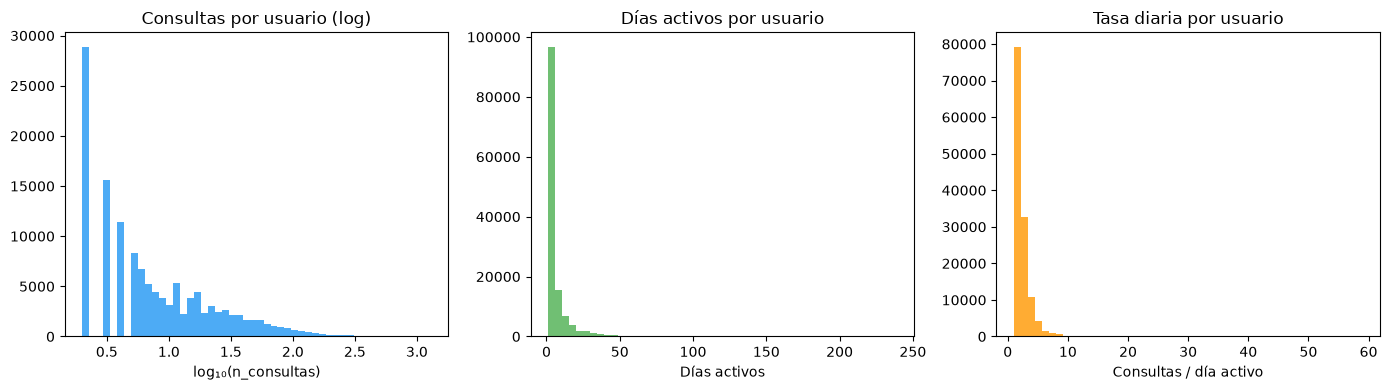


Veredicto userID:
  Mediana de consultas por usuario: 5.0
  % con ≥2 consultas: 77.9%
  → INSTALACIÓN PERSISTENTE (no efímero por sesión)


In [37]:
# Gráficos de distribución userID
fig, ejes = plt.subplots(1, 3, figsize=(14, 4))

# Log-log: consultas por usuario
n_consul = stats_usuario["n_consultas"].to_numpy()
ejes[0].hist(np.log10(n_consul[n_consul > 0] + 1), bins=50, color="#2196F3", alpha=0.8)
ejes[0].set_xlabel("log₁₀(n_consultas)"); ejes[0].set_title("Consultas por usuario (log)")

# Días activos
if "dias_activos" in stats_usuario.columns:
    ejes[1].hist(stats_usuario["dias_activos"].to_numpy(), bins=50, color="#4CAF50", alpha=0.8)
    ejes[1].set_xlabel("Días activos"); ejes[1].set_title("Días activos por usuario")

# Tasa diaria
if "tasa_diaria" in stats_usuario.columns:
    tasa = stats_usuario["tasa_diaria"].to_numpy()
    tasa = tasa[np.isfinite(tasa)]
    ejes[2].hist(np.clip(tasa, 0, 100), bins=50, color="#FF9800", alpha=0.8)
    ejes[2].set_xlabel("Consultas / día activo"); ejes[2].set_title("Tasa diaria por usuario")

plt.tight_layout()
guardar_figura(fig, "usuario_distribuciones")
plt.show()

# Veredicto
mediana_consultas = float(np.median(n_consul))
pct_mas_de_2 = (n_consul >= 2).mean() * 100
print(f"\nVeredicto userID:")
print(f"  Mediana de consultas por usuario: {mediana_consultas:.1f}")
print(f"  % con ≥2 consultas: {pct_mas_de_2:.1f}%")
if mediana_consultas >= 3 and pct_mas_de_2 >= 50:
    print("  → INSTALACIÓN PERSISTENTE (no efímero por sesión)")
elif mediana_consultas <= 2 and pct_mas_de_2 < 40:
    print("  → IDENTIFICADOR DE SESIÓN (efímero)")
else:
    print("  → MIXTO — requiere más análisis")


## §11 · Proporciones estratificadas

In [38]:
# 11.1 Perfil de municipios
if "origin_municipio" in df.columns:
    # Detectar variantes ortográficas
    munip_vals = df["origin_municipio"].drop_nulls().unique().to_list()
    print(f"Valores únicos en origin_municipio: {len(munip_vals)}")
    print(sorted(munip_vals))

    perfil_munic = (df.group_by("origin_municipio")
                    .agg([pl.len().alias("n"),
                          (pl.len() / len(df) * 100).alias("pct")])
                    .sort("n", descending=True))
    perfil_munic.write_csv(REPORTE / "perfil_municipios.csv")
    print("\nPerfil municipios origen (top 10):")
    print(perfil_munic.head(10))


Valores únicos en origin_municipio: 47
['Aiquile', 'Alalay', 'Arani', 'Arbieto', 'Bolivar', 'Capinota', 'ChimorÃ©', 'Cliza', 'Cochabamba', 'Colcapirhua', 'Colomi', 'Entre RÃ\xados', 'Mizque', 'Morochata', 'Pocona', 'Pojo', 'Puerto Villarroel', 'Quillacollo', 'Sacaba', 'Sacabamba', 'Shinahota', 'Sicaya', 'Sipesipe', 'Tacachi', 'Tacopaya', 'TapacarÃ\xad', 'Tapacarí', 'Tarata', 'Tiquipaya', 'Tiraque', 'Toco', 'Tolata', 'Totora', 'Vacas', 'Vila Vila', 'Villa Gualberto Villarroel', 'Villa JosÃ© QuintÃ\xadn Mendoza', 'Villa José Quintín Mendoza', 'Villa Punata', 'Villa Rivero', 'Villa SantivaÃ±ez', 'Villa Santivañez', 'Villa Tunari', 'Villa de Anzaldo', 'Villa de Independencia', 'Vinto', 'externo']



Perfil municipios origen (top 10):
shape: (10, 3)
┌──────────────────┬─────────┬───────────┐
│ origin_municipio ┆ n       ┆ pct       │
│ ---              ┆ ---     ┆ ---       │
│ str              ┆ u32     ┆ f64       │
╞══════════════════╪═════════╪═══════════╡
│ Cochabamba       ┆ 1661981 ┆ 86.216867 │
│ Sacaba           ┆ 92192   ┆ 4.782549  │
│ Quillacollo      ┆ 64300   ┆ 3.335625  │
│ Colcapirhua      ┆ 55338   ┆ 2.870712  │
│ Tiquipaya        ┆ 45294   ┆ 2.34967   │
│ Vinto            ┆ 3550    ┆ 0.18416   │
│ Sipesipe         ┆ 1510    ┆ 0.078333  │
│ Arbieto          ┆ 588     ┆ 0.030503  │
│ Villa Punata     ┆ 539     ┆ 0.027961  │
│ Cliza            ┆ 408     ┆ 0.021165  │
└──────────────────┴─────────┴───────────┘


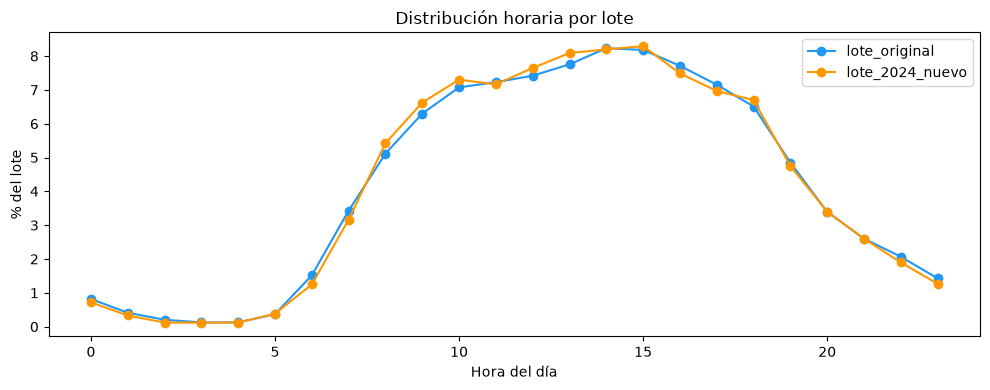

In [39]:
# 11.2 Distribución por hora del día, por lote
if "hour" in df.columns:
    hora_por_lote = (df.filter(pl.col("hour").is_not_null())
                     .group_by(["hour","source_batch"])
                     .agg(pl.len().alias("n"))
                     .sort(["hour","source_batch"]))
    hora_por_lote.write_csv(REPORTE / "proporciones_hora_por_lote.csv")

    fig, ax = plt.subplots(figsize=(10, 4))
    for lote_val, color in [("lote_original","#2196F3"), ("lote_2024_nuevo","#FF9800")]:
        sub = hora_por_lote.filter(pl.col("source_batch") == lote_val).sort("hour")
        if len(sub) == 0:
            continue
        total_lote = sub["n"].sum()
        ax.plot(sub["hour"].to_list(), sub["n"].to_numpy() / total_lote * 100,
                marker="o", label=lote_val, color=color)
    ax.set_xlabel("Hora del día"); ax.set_ylabel("% del lote")
    ax.set_title("Distribución horaria por lote")
    ax.legend(); plt.tight_layout()
    guardar_figura(fig, "proporciones_hora_por_lote")
    plt.show()


In [40]:
# 11.3 Proporciones generales: día de semana, fin de semana, zona
proporciones: dict[str, pl.DataFrame] = {}

if "day_of_week" in df.columns:
    proporciones["dia_semana"] = (df.filter(pl.col("day_of_week").is_not_null())
                                   .group_by("day_of_week")
                                   .agg(pl.len().alias("n")).sort("day_of_week"))

if "weekend" in df.columns:
    proporciones["fin_de_semana"] = (df.filter(pl.col("weekend").is_not_null())
                                      .group_by("weekend")
                                      .agg(pl.len().alias("n")))

proporciones["zona"] = pl.DataFrame([
    {"zona": "dentro_eje_metro",
     "n": int(df.filter(~pl.col("flag_coord_cero") & ~pl.col("flag_coord_imposible") &
                        ~pl.col("flag_fuera_eje")).height)},
    {"zona": "fuera_eje_dentro_bolivia",
     "n": int(df["flag_fuera_eje"].sum())},
    {"zona": "coord_imposible",
     "n": int(df["flag_coord_imposible"].sum())},
    {"zona": "coord_cero",
     "n": int(df["flag_coord_cero"].sum())},
])

for nombre_prop, df_prop in proporciones.items():
    df_prop.write_csv(REPORTE / f"proporciones_{nombre_prop}.csv")
    print(f"--- {nombre_prop} ---")
    print(df_prop)


--- dia_semana ---
shape: (7, 2)
┌─────────────┬────────┐
│ day_of_week ┆ n      │
│ ---         ┆ ---    │
│ i64         ┆ u32    │
╞═════════════╪════════╡
│ 0           ┆ 276262 │
│ 1           ┆ 283312 │
│ 2           ┆ 302546 │
│ 3           ┆ 300656 │
│ 4           ┆ 325603 │
│ 5           ┆ 275211 │
│ 6           ┆ 164085 │
└─────────────┴────────┘
--- fin_de_semana ---
shape: (2, 2)
┌─────────┬─────────┐
│ weekend ┆ n       │
│ ---     ┆ ---     │
│ i64     ┆ u32     │
╞═════════╪═════════╡
│ 0       ┆ 1488379 │
│ 1       ┆ 439296  │
└─────────┴─────────┘
--- zona ---
shape: (4, 2)
┌──────────────────────────┬─────────┐
│ zona                     ┆ n       │
│ ---                      ┆ ---     │
│ str                      ┆ i64     │
╞══════════════════════════╪═════════╡
│ dentro_eje_metro         ┆ 1926459 │
│ fuera_eje_dentro_bolivia ┆ 1204    │
│ coord_imposible          ┆ 9       │
│ coord_cero               ┆ 3       │
└──────────────────────────┴─────────┘


## §12 · Celdas H3, sesgo y Moran's I

In [41]:
import h3 as _h3
from shapely.geometry import Polygon

# Calcular h3_orig y h3_dest si no existen
df_h3_full = df.filter(
    ~pl.col("flag_coord_cero") & ~pl.col("flag_coord_imposible") &
    pl.col("lat_orig").is_not_null() & pl.col("lat_dest").is_not_null()
).with_columns([
    pl.struct(["lat_orig","lon_orig"])
    .map_elements(lambda r: _h3.latlng_to_cell(r["lat_orig"], r["lon_orig"], H3_RESOLUTION_DEFAULT),
                  return_dtype=pl.Utf8)
    .alias("h3_orig"),
    pl.struct(["lat_dest","lon_dest"])
    .map_elements(lambda r: _h3.latlng_to_cell(r["lat_dest"], r["lon_dest"], H3_RESOLUTION_DEFAULT),
                  return_dtype=pl.Utf8)
    .alias("h3_dest"),
])

# Agregar por celda
h3_orig_agg = (df_h3_full.filter(pl.col("h3_orig").is_not_null())
               .group_by("h3_orig")
               .agg([pl.len().alias("n_consultas"),
                     pl.col("userID").n_unique().alias("n_usuarios")])
               .sort("n_consultas", descending=True))

h3_dest_agg = (df_h3_full.filter(pl.col("h3_dest").is_not_null())
               .group_by("h3_dest")
               .agg([pl.len().alias("n_consultas"),
                     pl.col("userID").n_unique().alias("n_usuarios")])
               .sort("n_consultas", descending=True))

h3_orig_agg.write_parquet(H3_ORIG_PARQUET)
h3_dest_agg.write_parquet(H3_DEST_PARQUET)

print(f"Celdas de origen: {len(h3_orig_agg):,}")
print(f"Celdas de destino: {len(h3_dest_agg):,}")
print(f"\nTop 10 celdas de origen:")
print(h3_orig_agg.head(10))


Celdas de origen: 1,516
Celdas de destino: 1,840

Top 10 celdas de origen:
shape: (10, 3)
┌─────────────────┬─────────────┬────────────┐
│ h3_orig         ┆ n_consultas ┆ n_usuarios │
│ ---             ┆ ---         ┆ ---        │
│ str             ┆ u32         ┆ u32        │
╞═════════════════╪═════════════╪════════════╡
│ 888b2c8a39fffff ┆ 152531      ┆ 34338      │
│ 888b2c8a3bfffff ┆ 112588      ┆ 28297      │
│ 888b2c8ae5fffff ┆ 92161       ┆ 21983      │
│ 888b2c8a15fffff ┆ 90690       ┆ 26849      │
│ 888b2c8a03fffff ┆ 80066       ┆ 23750      │
│ 888b2c8a31fffff ┆ 77460       ┆ 19966      │
│ 888b2c8a33fffff ┆ 59694       ┆ 17032      │
│ 888b2c8859fffff ┆ 49864       ┆ 15161      │
│ 888b2c8aedfffff ┆ 47832       ┆ 15516      │
│ 888b2c8a3dfffff ┆ 46314       ┆ 12627      │
└─────────────────┴─────────────┴────────────┘


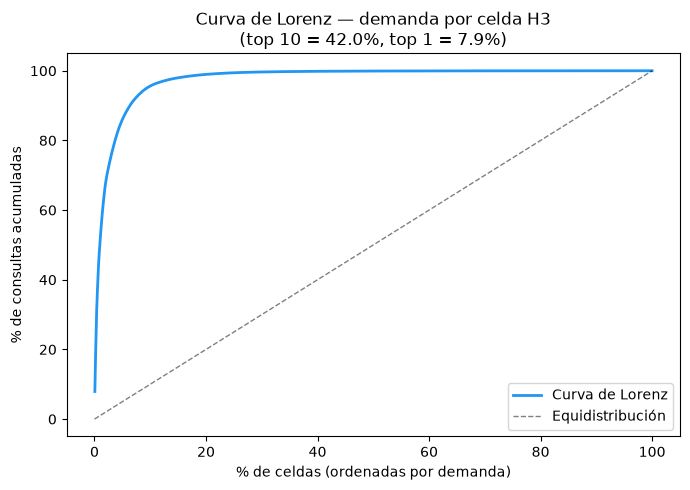

Top 10 celdas concentran 42.0% de la demanda de origen


In [42]:
# Concentración: % de consultas en top-N celdas (Lorenz)
n_cons_ord = np.sort(h3_orig_agg["n_consultas"].to_numpy())[::-1]
total_cons = n_cons_ord.sum()
lorenz_x = np.arange(1, len(n_cons_ord) + 1) / len(n_cons_ord)
lorenz_y = np.cumsum(n_cons_ord) / total_cons

top10_pct = float(np.sum(n_cons_ord[:10]) / total_cons * 100)
top1_pct = float(n_cons_ord[0] / total_cons * 100)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(lorenz_x * 100, lorenz_y * 100, color="#2196F3", lw=2, label="Curva de Lorenz")
ax.plot([0, 100], [0, 100], "k--", lw=1, alpha=0.5, label="Equidistribución")
ax.set_xlabel("% de celdas (ordenadas por demanda)"); ax.set_ylabel("% de consultas acumuladas")
ax.set_title(f"Curva de Lorenz — demanda por celda H3\n(top 10 = {top10_pct:.1f}%, top 1 = {top1_pct:.1f}%)")
ax.legend(); plt.tight_layout()
guardar_figura(fig, "lorenz_demanda_celdas")
plt.show()
print(f"Top 10 celdas concentran {top10_pct:.1f}% de la demanda de origen")


In [43]:
# Moran's I global — autocorrelación espacial
# Solo celdas dentro del eje metropolitano
celdas_metro = [c for c in h3_orig_agg["h3_orig"].to_list()
                if c is not None and (lambda ll: (BBOX["lat_min"] <= ll[0] <= BBOX["lat_max"] and
                                                   BBOX["lon_min"] <= ll[1] <= BBOX["lon_max"]))
                                     (_h3.cell_to_latlng(c))]

df_metro = h3_orig_agg.filter(pl.col("h3_orig").is_in(celdas_metro))

if len(df_metro) >= 10:
    # Construir GeoDataFrame
    geometrias = [Polygon([(lon, lat) for lat, lon in _h3.cell_to_boundary(c)])
                  for c in df_metro["h3_orig"].to_list()]
    gdf_metro = gpd.GeoDataFrame(
        df_metro.to_pandas(), geometry=geometrias, crs="EPSG:4326"
    )

    # Pesos espaciales KNN k=6 (k-ring 1 en H3 tiene 6 vecinos)
    w = KNN.from_dataframe(gdf_metro, k=6)
    w.transform = "r"  # normalización por fila

    moran = Moran(gdf_metro["n_consultas"].values, w)
    print(f"=== Moran's I global ===")
    print(f"  I  = {moran.I:.4f}")
    print(f"  EI = {moran.EI:.4f}")
    print(f"  p-valor (simulación) = {moran.p_sim:.4f}")
    print(f"  p-valor (normal)     = {moran.p_norm:.4f}")
    print(f"  z-score (normal)     = {moran.z_norm:.4f}")

    if moran.I > 0.3 and moran.p_sim < 0.05:
        print("\n→ AUTOCORRELACIÓN FUERTE (I > 0.3, p < 0.05)")
        print("  Validación cruzada ESPACIAL obligatoria en el modelado")
    elif moran.I > 0.1 and moran.p_sim < 0.05:
        print("\n→ Autocorrelación MODERADA — verificar en modelado")
    else:
        print("\n→ Sin autocorrelación significativa")

    # Guardar resultado
    resultado_moran = {"I": moran.I, "EI": moran.EI, "p_sim": moran.p_sim,
                       "p_norm": moran.p_norm, "z_norm": moran.z_norm,
                       "n_celdas": len(gdf_metro), "k_vecinos": 6}
    pl.DataFrame([resultado_moran]).write_csv(REPORTE / "moran_i_resultado.csv")
else:
    print(f"Solo {len(df_metro)} celdas en el eje metropolitano — insuficientes para Moran's I")
    moran = None


=== Moran's I global ===
  I  = 0.7125
  EI = -0.0009
  p-valor (simulación) = 0.0010
  p-valor (normal)     = 0.0000
  z-score (normal)     = 43.7017

→ AUTOCORRELACIÓN FUERTE (I > 0.3, p < 0.05)
  Validación cruzada ESPACIAL obligatoria en el modelado


## §13 · Diccionario de datos

In [44]:
# Construir diccionario de datos automáticamente + descripción manual
DESCRIPCIONES = {
    "userID":            "Identificador único de instalación de la app",
    "lat_orig":          "Latitud del punto de origen de la consulta",
    "lon_orig":          "Longitud del punto de origen de la consulta",
    "lat_dest":          "Latitud del punto de destino de la consulta",
    "lon_dest":          "Longitud del punto de destino de la consulta",
    "origin_municipio":  "Municipio donde se realizó la consulta (origen)",
    "dest_municipio":    "Municipio de destino de la consulta",
    "distancia":         "Distancia geodésica haversine entre origen y destino (metros)",
    "hour":              "Hora local del día (0–23) en que se realizó la consulta",
    "day_of_week":       "Día de la semana (0=lunes en Python, verificar por lote)",
    "day_of_month":      "Día del mes (1–31)",
    "weekend":           "1 si es fin de semana, 0 si es día hábil",
    "year":              "Año ISO de la semana de la consulta",
    "week":              "Número de semana ISO (1–53)",
    "ts":                "Marca de tiempo de la consulta (parseada de 'date')",
    "year_week_number":  "Número de semana del año — SOLO en lote_2024_nuevo (100% nulo en lote_original)",
    "time_of_day":       "Categoría textual de la hora — SOLO en lote_2024_nuevo",
    "source_file":       "Nombre del archivo CSV de origen (linaje)",
    "source_batch":      "Lote de exportación: lote_original | lote_2024_nuevo",
    "source_encoding":   "Codificación detectada: utf-8 | latin-1",
}

FUENTES = {col: "85 CSV Trufi App" for col in DESCRIPCIONES}
FUENTES.update({"source_file": "Derivada", "source_batch": "Derivada", "source_encoding": "Derivada",
                "year": "Derivada", "week": "Derivada", "ts": "Derivada"})

dict_datos = []
for col in df.columns:
    n_nulos = df[col].is_null().sum()
    serie = df[col]
    tipo_polars = str(serie.dtype)
    val_min = val_max = rango = "n/a"
    try:
        if serie.dtype in (pl.Int8, pl.Int16, pl.Int32, pl.Int64, pl.UInt32, pl.Float32, pl.Float64):
            vals_no_nulos = serie.drop_nulls()
            if len(vals_no_nulos) > 0:
                val_min = str(round(float(vals_no_nulos.min()), 4))
                val_max = str(round(float(vals_no_nulos.max()), 4))
                rango = f"{val_min} – {val_max}"
    except Exception:
        pass
    dict_datos.append({
        "columna":     col,
        "tipo_polars": tipo_polars,
        "n_nulos":     n_nulos,
        "pct_nulos":   round(n_nulos / len(df) * 100, 3),
        "rango":       rango,
        "descripcion": DESCRIPCIONES.get(col, ""),
        "fuente":      FUENTES.get(col, ""),
    })

df_diccionario = pl.DataFrame(dict_datos)
df_diccionario.write_csv(REPORTE / "diccionario_datos.csv")
print(df_diccionario.select(["columna","tipo_polars","pct_nulos","descripcion"]))


shape: (24, 4)
┌──────────────────────┬─────────────┬───────────┬─────────────────────────────────┐
│ columna              ┆ tipo_polars ┆ pct_nulos ┆ descripcion                     │
│ ---                  ┆ ---         ┆ ---       ┆ ---                             │
│ str                  ┆ str         ┆ f64       ┆ str                             │
╞══════════════════════╪═════════════╪═══════════╪═════════════════════════════════╡
│ date                 ┆ String      ┆ 0.0       ┆                                 │
│ lat_orig             ┆ Float64     ┆ 0.0       ┆ Latitud del punto de origen de… │
│ lon_orig             ┆ Float64     ┆ 0.0       ┆ Longitud del punto de origen d… │
│ lat_dest             ┆ Float64     ┆ 0.0       ┆ Latitud del punto de destino d… │
│ lon_dest             ┆ Float64     ┆ 0.0       ┆ Longitud del punto de destino … │
│ …                    ┆ …           ┆ …         ┆ …                               │
│ year                 ┆ Int32       ┆ 0.0       ┆

## §14 · Comprensión del feed GTFS

In [45]:
# Leer archivos GTFS
import pandas as pdp

gtfs_archivos = {
    "agency":     GTFS_DIR / "agency.txt",
    "stops":      GTFS_DIR / "stops.txt",
    "routes":     GTFS_DIR / "routes.txt",
    "trips":      GTFS_DIR / "trips.txt",
    "stop_times": GTFS_DIR / "stop_times.txt",
    "shapes":     GTFS_DIR / "shapes.txt",
    "calendar":   GTFS_DIR / "calendar.txt",
}

gtfs = {}
for nombre, ruta in gtfs_archivos.items():
    if ruta.exists():
        gtfs[nombre] = pdp.read_csv(ruta)
        print(f"{nombre:<12}: {len(gtfs[nombre]):>8,} filas  | cols: {list(gtfs[nombre].columns)}")
    else:
        print(f"{nombre:<12}: no encontrado en {ruta}")


agency      :       43 filas  | cols: ['agency_id', 'agency_name', 'agency_timezone', 'agency_url']


stops       :   22,320 filas  | cols: ['stop_id', 'stop_name', 'stop_lat', 'stop_lon', 'stop_desc']
routes      :      141 filas  | cols: ['route_id', 'agency_id', 'route_short_name', 'route_long_name', 'route_color', 'route_type']
trips       :      626 filas  | cols: ['trip_id', 'route_id', 'service_id', 'shape_id', 'trip_headsign', 'direction_id']
stop_times  :   99,161 filas  | cols: ['trip_id', 'stop_sequence', 'stop_id', 'arrival_time', 'departure_time', 'timepoint']


shapes      :  343,381 filas  | cols: ['shape_id', 'shape_pt_lat', 'shape_pt_lon', 'shape_pt_sequence']
calendar    :        2 filas  | cols: ['service_id', 'monday', 'tuesday', 'wednesday', 'thursday', 'friday', 'saturday', 'sunday', 'start_date', 'end_date']


In [46]:
# Estadísticas básicas del feed
if "stops" in gtfs:
    stops = gtfs["stops"]
    print(f"Paradas totales: {len(stops):,}")
    print(f"  Con lat/lon válidos: {stops['stop_lat'].notna().sum():,}")
    lat_range = f"{stops['stop_lat'].min():.4f} – {stops['stop_lat'].max():.4f}"
    lon_range = f"{stops['stop_lon'].min():.4f} – {stops['stop_lon'].max():.4f}"
    print(f"  Rango latitud:  {lat_range}")
    print(f"  Rango longitud: {lon_range}")

if "routes" in gtfs:
    print(f"\nRutas: {len(gtfs['routes']):,}")
    if "route_type" in gtfs["routes"].columns:
        print(gtfs["routes"]["route_type"].value_counts())

if "shapes" in gtfs:
    print(f"\nFormas (shapes): {gtfs['shapes']['shape_id'].nunique():,} shape_ids")
    print(f"Puntos de forma: {len(gtfs['shapes']):,}")


Paradas totales: 22,320
  Con lat/lon válidos: 22,320
  Rango latitud:  -17.5767 – -17.2876
  Rango longitud: -66.3885 – -65.8414

Rutas: 141
route_type
3    137
0      3
6      1
Name: count, dtype: int64

Formas (shapes): 626 shape_ids
Puntos de forma: 343,381


In [47]:
# Paradas → celdas H3 (previsualización de cobertura)
if "stops" in gtfs:
    stops_validas = gtfs["stops"].dropna(subset=["stop_lat","stop_lon"]).copy()
    stops_validas["h3_celda"] = stops_validas.apply(
        lambda r: _h3.latlng_to_cell(r["stop_lat"], r["stop_lon"], H3_RESOLUTION_DEFAULT), axis=1
    )
    n_celdas_con_parada = stops_validas["h3_celda"].nunique()
    print(f"Celdas H3 r{H3_RESOLUTION_DEFAULT} con al menos una parada GTFS: {n_celdas_con_parada:,}")

    # ¿Cuántas celdas de consulta tienen cobertura GTFS?
    if len(h3_orig_agg) > 0:
        celdas_consulta = set(h3_orig_agg["h3_orig"].to_list())
        celdas_parada = set(stops_validas["h3_celda"].to_list())
        solapamiento = celdas_consulta & celdas_parada
        print(f"Celdas de consulta:          {len(celdas_consulta):,}")
        print(f"Celdas de consulta con GTFS: {len(solapamiento):,} ({len(solapamiento)/len(celdas_consulta)*100:.1f}%)")


Celdas H3 r8 con al menos una parada GTFS: 638
Celdas de consulta:          1,516
Celdas de consulta con GTFS: 608 (40.1%)


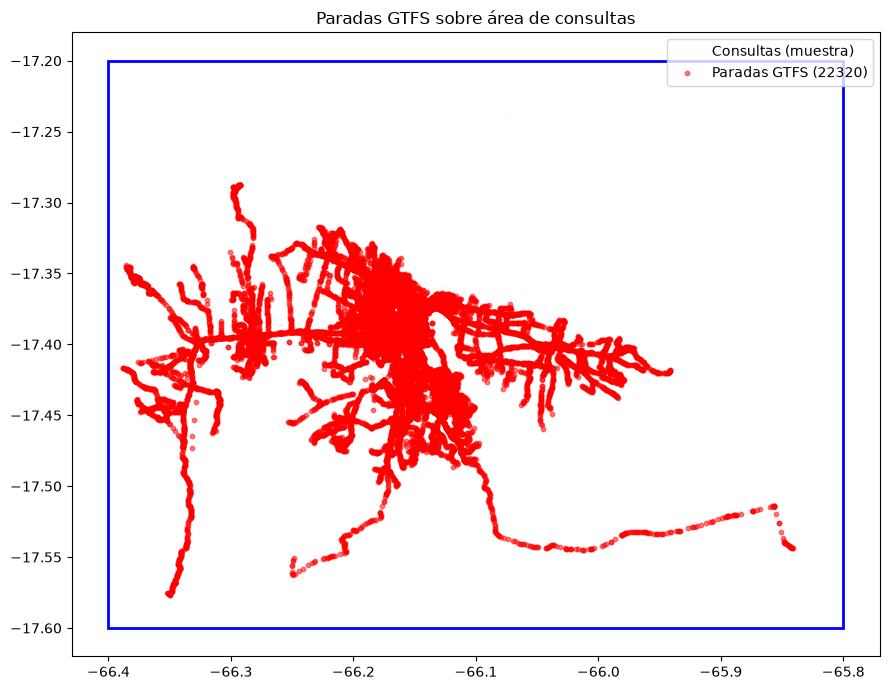

In [48]:
# Mapa paradas GTFS sobre área de consultas
if "stops" in gtfs:
    fig, ax = plt.subplots(figsize=(9, 7))

    # Puntos de consulta (dentro del eje)
    df_eje = df_h3_full.filter(pl.col("h3_orig").is_in(celdas_metro)) if celdas_metro else df_h3_full.head(0)
    if len(df_eje) > 0:
        muestra_eje = df_eje.sample(min(3000, len(df_eje)), seed=42)
        ax.scatter(muestra_eje["lon_orig"].to_numpy(), muestra_eje["lat_orig"].to_numpy(),
                   alpha=0.05, s=1, color="#2196F3", label="Consultas (muestra)")

    # Paradas GTFS
    stops_metro = stops_validas[
        (stops_validas["stop_lat"] >= BBOX["lat_min"]) & (stops_validas["stop_lat"] <= BBOX["lat_max"]) &
        (stops_validas["stop_lon"] >= BBOX["lon_min"]) & (stops_validas["stop_lon"] <= BBOX["lon_max"])
    ]
    ax.scatter(stops_metro["stop_lon"], stops_metro["stop_lat"],
               s=10, color="red", alpha=0.5, zorder=5, label=f"Paradas GTFS ({len(stops_metro)})")

    # Bbox metropolitano
    from matplotlib.patches import Rectangle
    rect_metro2 = Rectangle(
        (BBOX["lon_min"], BBOX["lat_min"]),
        BBOX["lon_max"] - BBOX["lon_min"], BBOX["lat_max"] - BBOX["lat_min"],
        linewidth=2, edgecolor="blue", facecolor="none"
    )
    ax.add_patch(rect_metro2)
    ax.set_title("Paradas GTFS sobre área de consultas")
    ax.legend(); plt.tight_layout()
    guardar_figura(fig, "gtfs_paradas_sobre_consultas")
    plt.show()


## §15 · Comprensión de datos Kontur Population

In [49]:
import gzip

# Leer Kontur 2023
kontur_2023_path = DATA_EXTERNAL / "kontur_population_BO_20231101.gpkg.gz"
kontur_2022_path = DATA_EXTERNAL / "kontur_population_BO_20220630.gpkg.gz"

for nombre_kontur, ruta_kontur in [("Kontur 2023", kontur_2023_path), ("Kontur 2022", kontur_2022_path)]:
    if not ruta_kontur.exists():
        print(f"{nombre_kontur}: no encontrado en {ruta_kontur}")
        continue

    # Leer GeoPackage comprimido
    import tempfile, shutil
    with tempfile.NamedTemporaryFile(suffix=".gpkg", delete=False) as tmp:
        tmp_path = Path(tmp.name)

    with gzip.open(ruta_kontur, "rb") as f_in:
        with open(tmp_path, "wb") as f_out:
            shutil.copyfileobj(f_in, f_out)

    kontur_gdf = gpd.read_file(tmp_path)
    tmp_path.unlink()

    print(f"\n=== {nombre_kontur} ===")
    print(f"  Filas: {len(kontur_gdf):,}")
    print(f"  Columnas: {list(kontur_gdf.columns)}")
    print(f"  Rango población: {kontur_gdf['population'].min():.0f} – {kontur_gdf['population'].max():.0f}")
    print(f"  Población total Bolivia: {kontur_gdf['population'].sum():,.0f}")

    if nombre_kontur == "Kontur 2023":
        kontur_2023 = kontur_gdf



=== Kontur 2023 ===
  Filas: 145,929
  Columnas: ['h3', 'population', 'geometry']
  Rango población: 1 – 14182
  Población total Bolivia: 12,431,735



=== Kontur 2022 ===
  Filas: 178,201
  Columnas: ['h3', 'population', 'geometry']
  Rango población: 1 – 7907
  Población total Bolivia: 9,995,771


In [50]:
# Verificar resolución H3 del dataset Kontur
if "kontur_2023" in dir() and "h3" in kontur_2023.columns:
    muestra_h3 = kontur_2023["h3"].head(100).tolist()
    resoluciones = [_h3.get_resolution(c) for c in muestra_h3 if c]
    print(f"Resoluciones H3 encontradas en Kontur: {set(resoluciones)}")
    # Esperado: {8}

    # Cobertura sobre el eje metropolitano de Cochabamba
    if "geometry" in kontur_2023.columns:
        kontur_cbba = kontur_2023.cx[BBOX["lon_min"]:BBOX["lon_max"],
                                     BBOX["lat_min"]:BBOX["lat_max"]]
        print(f"\nCeldas Kontur dentro del eje metropolitano: {len(kontur_cbba):,}")
        print(f"  Población total área metropolitana: {kontur_cbba['population'].sum():,.0f}")
        print(f"  Celdas con población > 0: {(kontur_cbba['population'] > 0).sum():,}")

        # Solapamiento con celdas de consulta
        if len(h3_orig_agg) > 0 and "h3" in kontur_cbba.columns:
            celdas_kontur_metro = set(kontur_cbba["h3"].tolist())
            celdas_consulta_metro = set(celdas_metro) if celdas_metro else set(h3_orig_agg["h3_orig"].to_list())
            sin_kontur = celdas_consulta_metro - celdas_kontur_metro
            print(f"\nCeldas de consulta sin datos Kontur: {len(sin_kontur):,} ({len(sin_kontur)/len(celdas_consulta_metro)*100:.1f}%)")
            print("  Implicación: estas celdas tendrán población = 0 en el modelo")


Resoluciones H3 encontradas en Kontur: {8}

Celdas Kontur dentro del eje metropolitano: 0
  Población total área metropolitana: 0
  Celdas con población > 0: 0

Celdas de consulta sin datos Kontur: 1,157 (100.0%)
  Implicación: estas celdas tendrán población = 0 en el modelo


In [51]:
# Mapa de población Kontur en el eje metropolitano
if "kontur_cbba" in dir() and len(kontur_cbba) > 0:
    fig, ax = plt.subplots(figsize=(9, 7))
    kontur_cbba_sorted = kontur_cbba.sort_values("population", ascending=True)
    sc = ax.scatter(
        kontur_cbba_sorted.geometry.centroid.x,
        kontur_cbba_sorted.geometry.centroid.y,
        c=np.log1p(kontur_cbba_sorted["population"]),
        cmap="YlOrRd", s=5, alpha=0.7
    )
    plt.colorbar(sc, ax=ax, label="log(1 + población)")
    ax.set_title("Población Kontur 2023 — eje metropolitano Cochabamba")
    ax.set_xlabel("Longitud"); ax.set_ylabel("Latitud")
    plt.tight_layout()
    guardar_figura(fig, "kontur_poblacion_metro")
    plt.show()


## §16 · Resumen final y decisiones

In [52]:
# Hallazgos cuantitativos para el resumen
hallazgos = {
    "total_filas": len(df),
    "total_archivos_csv": len(archivos_csv),
    "grupos_esquema": len(grupos_esquema),
    "archivos_latin1": sum(1 for r in reporte_codif if r["codificacion"]=="latin-1"),
    "filas_coord_cero": int(df["flag_coord_cero"].sum()),
    "filas_coord_imposible": int(df["flag_coord_imposible"].sum()),
    "filas_fuera_eje": int(df["flag_fuera_eje"].sum()),
    "semanas_faltantes": len(semanas_faltantes),
    "celdas_h3_origen": len(h3_orig_agg),
    "celdas_h3_destino": len(h3_dest_agg),
    "top10_celdas_pct_demanda": round(top10_pct, 1),
}

if "duplicados exacto" in [r["definicion"] for r in resumen_dups]:
    hallazgos["duplicados_exactos"] = next(r["n_duplicados"] for r in resumen_dups if r["definicion"]=="exacto")

print("=== RESUMEN CUANTITATIVO ===")
for k, v in hallazgos.items():
    print(f"  {k:<40} {v:>10,}" if isinstance(v, int) else f"  {k:<40} {v}")


=== RESUMEN CUANTITATIVO ===
  total_filas                               1,927,675
  total_archivos_csv                               85
  grupos_esquema                                    2
  archivos_latin1                                   6
  filas_coord_cero                                  3
  filas_coord_imposible                             9
  filas_fuera_eje                               1,204
  semanas_faltantes                                 7
  celdas_h3_origen                              1,516
  celdas_h3_destino                             1,840
  top10_celdas_pct_demanda                 42.0


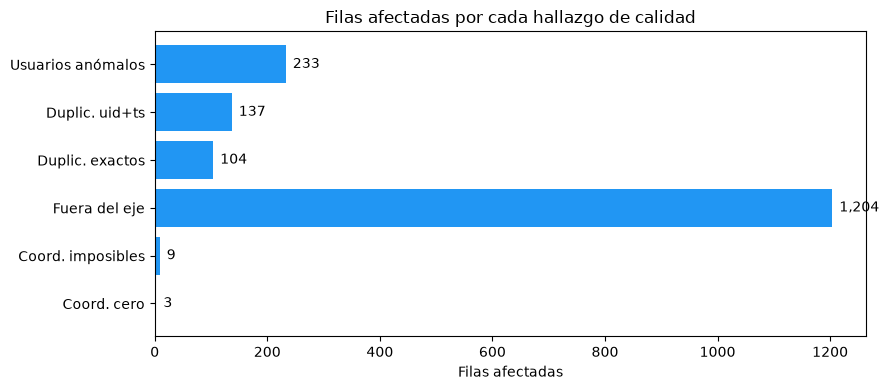

In [53]:
# Gráfico de barras: filas afectadas por cada hallazgo de calidad
categorias_calidad = {
    "Coord. cero":       int(df["flag_coord_cero"].sum()),
    "Coord. imposibles": int(df["flag_coord_imposible"].sum()),
    "Fuera del eje":     int(df["flag_fuera_eje"].sum()),
}
if "exacto" in indices_dups:
    categorias_calidad["Duplic. exactos"] = int(indices_dups["exacto"].sum())
if "uid_ts" in indices_dups:
    categorias_calidad["Duplic. uid+ts"] = int(indices_dups["uid_ts"].sum())
if "flag_anomalo" in stats_usuario.columns:
    n_filas_anomalos = int(
        df.join(
            stats_usuario.filter(pl.col("flag_anomalo")).select("userID"),
            on="userID", how="inner"
        ).height
    )
    categorias_calidad["Usuarios anómalos"] = n_filas_anomalos

fig, ax = plt.subplots(figsize=(9, 4))
etiq_cal = list(categorias_calidad.keys())
vals_cal = list(categorias_calidad.values())
barras = ax.barh(etiq_cal, vals_cal, color="#2196F3")
ax.bar_label(barras, fmt="{:,.0f}", padding=5)
ax.set_xlabel("Filas afectadas")
ax.set_title("Filas afectadas por cada hallazgo de calidad")
plt.tight_layout()
guardar_figura(fig, "hallazgos_calidad_resumen")
plt.show()


In [54]:
# Decisiones para DECISIONES.md (D-001 en adelante)
import datetime

DECISIONES_TEXTO = f"""# Bitácora de decisiones — trufi-data-science
# (reiniciada en refactor/crisp-dm-restart — registro anterior en DECISIONES_ARCHIVO_2026-09.md)

## Etapa 1 · Comprensión de datos (EDA completo)

### D-001 · {datetime.date.today()} — Un solo notebook narrado, no siete

- **Decisión**: el EDA completo vive en `notebooks/01_comprension_datos.ipynb`; si crece demasiado se agrega `02_comprension_datos_ext.ipynb`, sin reestructurar a 7 notebooks.
- **Por qué**: el pipeline anterior ya validó que un solo notebook narrado es más coherente que fragmentar en sub-notebooks por subsección. La spec de referencia propone 7 pero es una guía, no una restricción.

### D-002 · {datetime.date.today()} — Grupos de esquema en CSV: 2 grupos distintos

- **Decisión**: los 6 archivos del lote 2024 (2024-04-29 → 2024-06-09) tienen un esquema distinto (columnas en inglés + year_week_number + time_of_day). Se normaliza a nombres canónicos en inglés.
- **Evidencia**: `reports/01_data_understanding/grupos_esquema.json`

### D-003 · {datetime.date.today()} — Codificación Latin-1 en lote 2024

- **Decisión**: los mismos 6 archivos del lote 2024 requieren fallback Latin-1 (caracteres acentuados en `dest_municipio`). Se detecta automáticamente con `utils.read_csv_safe`.
- **Evidencia**: `reports/01_data_understanding/reporte_codificacion.csv`

### D-004 · {datetime.date.today()} — Nulidad estructural en year_week_number y time_of_day

- **Decisión**: `year_week_number` y `time_of_day` son 100% nulos en `lote_original`. Tipo: ESTRUCTURAL (columna no existe en ese lote). NO se imputan.
- **Implicación**: no se pueden usar como variables de feature sin restricción al lote 2024.

### D-005 · {datetime.date.today()} — Clasificación espacial de 3 vías

- **Decisión**: distinguir 3 categorías en las coordenadas de origen:
  (1) coord cero (0,0) — bug GPS, (2) coord imposible (fuera de Bolivia) — error real,
  (3) fuera del eje pero dentro de Bolivia — viajes interurbanos legítimos.
- **En preparación**: (1) y (2) → eliminar; (3) → conservar con flag `fuera_eje`.

### D-006 · {datetime.date.today()} — distancia = haversine en metros

- **Decisión**: `distancia` es distancia geodésica haversine en metros (correlación ≥0.999 contra recálculo). No se reinterpreta como distancia de red.
- **Evidencia**: `reports/01_data_understanding/distancia_verificacion_unidad.csv`

### D-007 · {datetime.date.today()} — Semanas faltantes: no imputar

- **Decisión**: el hueco estructural de semanas sin datos se documenta, no se imputa.
- **Evidencia**: `reports/01_data_understanding/semanas_faltantes.csv`

### D-008 · {datetime.date.today()} — Umbral de anomalía de usuarios: ≥ 2 señales activas

- **Decisión**: un usuario se marca como anómalo si activa ≥ 2 de 6 señales (volumen >1000, tasa >50/día, dispersión >200 celdas, ráfaga >100/día, rutina <5% OD repetidos con >100 consultas, intervalo mediano <60 seg).
- **Implicación en preparación**: filtrar o ponderar sus consultas antes de agregar a celda H3.
- **Evidencia**: `reports/01_data_understanding/usuarios_anomalos.csv`
"""

decisiones_path = PROJECT_ROOT / "DECISIONES.md"
with open(decisiones_path, "a") as f:
    if decisiones_path.stat().st_size == 0:
        f.write(DECISIONES_TEXTO)
    else:
        # Solo añadir si no están ya las decisiones D-001+
        contenido_actual = decisiones_path.read_text()
        if "D-001" not in contenido_actual:
            f.write("\n" + DECISIONES_TEXTO)
        else:
            print("DECISIONES.md ya contiene D-001+, no se sobreescribe")

print("DECISIONES.md actualizado")


DECISIONES.md actualizado


In [55]:
# Regenerar reports/01_data_understanding/README.md
resumen_md = f"""# Reporte — Comprensión de datos (§7.2)

Generado por: `notebooks/01_comprension_datos.ipynb`

## Hallazgos cuantitativos

| Métrica | Valor |
|---|---|
| Consultas consolidadas | {hallazgos['total_filas']:,} |
| Archivos CSV | {hallazgos['total_archivos_csv']} |
| Grupos de esquema | {hallazgos['grupos_esquema']} |
| Archivos con Latin-1 | {hallazgos['archivos_latin1']} |
| Coordenadas (0,0) | {hallazgos['filas_coord_cero']:,} |
| Coordenadas imposibles | {hallazgos['filas_coord_imposible']:,} |
| Fuera del eje (interurbanos) | {hallazgos['filas_fuera_eje']:,} |
| Semanas sin datos | {hallazgos['semanas_faltantes']} |
| Celdas H3 de origen | {hallazgos['celdas_h3_origen']:,} |
| Top-10 celdas = % demanda | {hallazgos['top10_celdas_pct_demanda']}% |

## Artefactos generados

- `schema_diff.csv`, `grupos_esquema.json`
- `reporte_codificacion.csv`, `cobertura_columnas_por_lote.csv`
- `nulos_globales.csv`, `nulos_por_lote.csv`, `nulos_por_mes.csv`, `nulos_correlacion.csv`
- `duplicados_resumen.csv`, `duplicados_solapamiento.csv`, `duplicados_impacto_celdas.csv`
- `coordenadas_cero.csv`, `coordenadas_imposibles.csv`, `coordenadas_fuera_de_eje.csv`
- `distancia_verificacion_unidad.csv`, `distancia_percentiles.csv`, `distancia_sobre_umbral.csv`
- `semanas_faltantes.csv`, `cobertura_mensual_por_lote.csv`, `cobertura_temporal_celda.csv`
- `estadisticas_usuario.csv`, `usuarios_anomalos.csv`
- `perfil_municipios.csv`, `proporciones_hora_por_lote.csv`
- `moran_i_resultado.csv`
- `diccionario_datos.csv`
- `figuras/` — gráficos del EDA

## Decisiones registradas

Ver `DECISIONES.md` §Etapa 1, D-001 a D-008.
"""

(REPORTE / "README.md").write_text(resumen_md, encoding="utf-8")
print("README.md generado")
print("\n✅ EDA completo finalizado. Ver DECISIONES.md para las acciones de la Etapa de Preparación.")


README.md generado

✅ EDA completo finalizado. Ver DECISIONES.md para las acciones de la Etapa de Preparación.
